In [ ]:
from src.controllers.DataLoader import DataLoader
from src.mappers.top_pathogens import ALL_PATHOGENS
from src.runners.DataProcessing import save_parquet_flat

parquet_dir = "./datasets/structured/dataset_parquet/"
loader = DataLoader(parquet_dir, pathogen_groups_regex=ALL_PATHOGENS)  # ensure DataLoader reads parquet dirs
df = loader.get_combined(return_which="tested")

# save_parquet_flat(df=df, out_dir="./datasets/WHO_Aware_data_resistance", rows_per_file=250_000)

In [6]:
exempt_cols = ['NumberOrganisation', 'OrgType', 'Anonymized_Lab']
features_df = df.drop(columns=exempt_cols, errors='ignore')
save_parquet_flat(
    df=features_df,
    out_dir="./datasets/WHO_Aware_data_tested",
    rows_per_file=250_000
)

PosixPath('datasets/WHO_Aware_data_tested')

In [7]:
features_df

,Pathogen,PathogengroupL1,GramType,Sex,Date,PathogenGenus,TextMaterialgroupRkiL0,AgeGroup,AgeRange,CareType,...,RAM - Rifampicin_Tested,ROX - Roxithromycin_Tested,TOB - Tobramycin_Tested,TPL - Teicoplanin_Tested,VAN - Vancomycin_Tested,AZT - Aztreonam_Tested,COL - Colistin_Tested,DPT - Daptomycin_Tested,LIZ - Linezolid_Tested,TGC - Tigecyclin_Tested
0,Escherichia coli,Gram-negative: Enterobacterales,Gram-negative,Woman,2020-09-08,Escherichia,Urine,Elderly,80-84 years,In-Patient,...,0,0,1,0,0,1,1,0,0,0
2,Klebsiella oxytoca,Gram-negative: Enterobacterales,Gram-negative,Man,2022-09-08,Klebsiella,Urine,Elderly,90-94 years,In-Patient,...,0,0,1,0,0,1,1,0,0,0
3,Klebsiella pneumoniae,Gram-negative: Enterobacterales,Gram-negative,Woman,2022-12-20,Klebsiella,Wound,Elderly,65-69 years,In-Patient,...,0,0,1,0,0,1,1,0,0,0
5,Escherichia coli,Gram-negative: Enterobacterales,Gram-negative,Woman,2022-07-20,Escherichia,Urine,Elderly,80-84 years,In-Patient,...,0,0,1,0,0,1,1,0,0,0
6,Staphylococcus aureus,Gram-positive: Staphylococci,Gram-positive,Man,2022-12-01,Staphylococcus,Wound,Elderly,70-74 years,In-Patient,...,0,0,0,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412163,Staphylococcus aureus,Gram-positive: Staphylococci,Gram-positive,Others,2022-10-11,Staphylococcus,Wound,Adult,55-59 years,In-Patient,...,1,0,0,0,1,0,0,1,1,1
412167,Escherichia coli,Gram-negative: Enterobacterales,Gram-negative,Man,2022-03-01,Escherichia,Urine,Adult,60-64 years,In-Patient,...,0,0,0,0,0,0,0,0,0,0
412168,Escherichia coli,Gram-negative: Enterobacterales,Gram-negative,Man,2021-08-19,Escherichia,Wound,Adult,55-59 years,In-Patient,...,0,0,1,0,0,0,0,0,0,0
412170,Proteus mirabilis,Gram-negative: Enterobacterales,Gram-negative,Others,2021-10-29,Proteus,Wound,Elderly,75-79 years,In-Patient,...,0,0,0,0,0,0,0,0,0,0


Install with: pip install pgmpy
Generating publication-quality exclusion analysis...

Loading and preprocessing data...
Dataset loaded: 328914 rows, 88 columns
Found 52 antibiotic columns
Processing 52 antibiotic columns...
Binarization: R=1 (resistant), S/I=0 (non-resistant)

Filtering antibiotics with exclusion tracking...
Filtered antibiotics: 39 removed, 13 kept

Excluded antibiotics and reasons:
  CMP - Chloramphenicol_Outcome:
    Resistance rate: 0.126
    Valid samples: 11976/328914
    - High missing rate (96.4%)
  COX - Cefoxitin_Outcome:
    Resistance rate: 0.140
    Valid samples: 6560/328914
    - High missing rate (98.0%)
  NFT - Nitrofurantoin_Outcome:
    Resistance rate: 0.168
    Valid samples: 139840/328914
    - High missing rate (57.5%)
  MCL - Mecillinam_Outcome:
    Resistance rate: 0.153
    Valid samples: 94665/328914
    - High missing rate (71.2%)
  AMK - Amikacin_Outcome:
    Resistance rate: 0.032
    Valid samples: 44467/328914
    - High missing rate (86

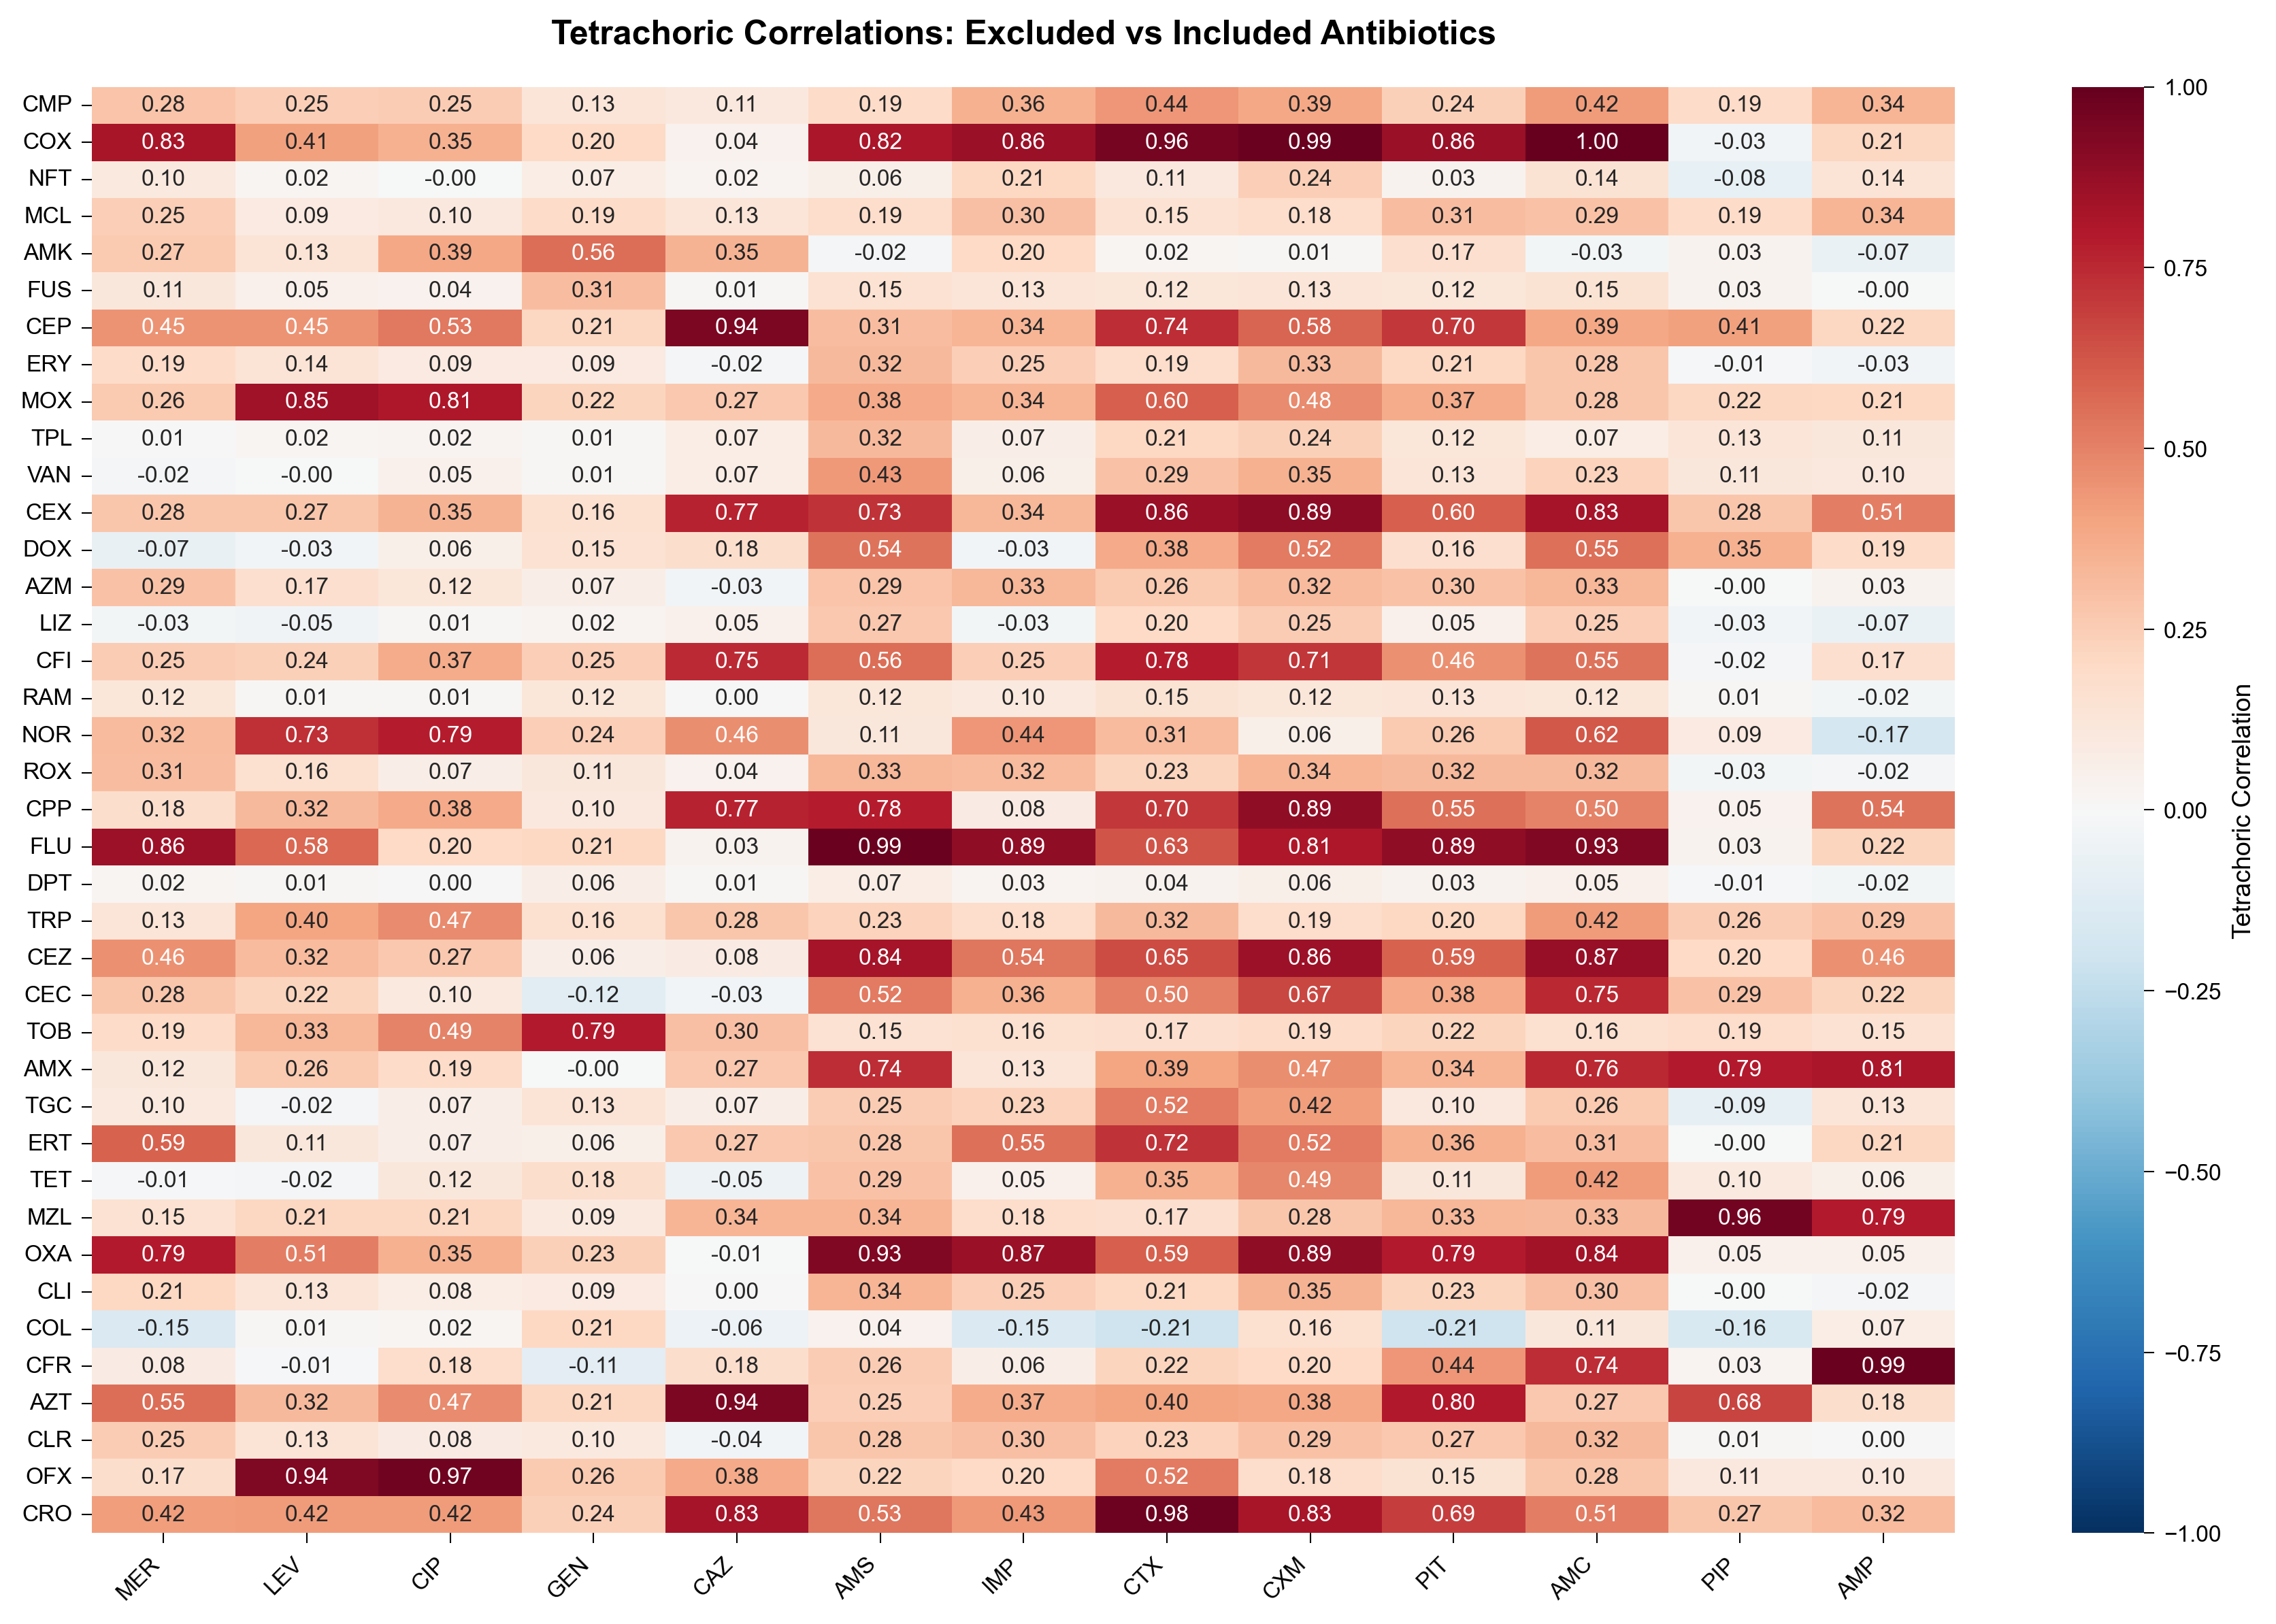

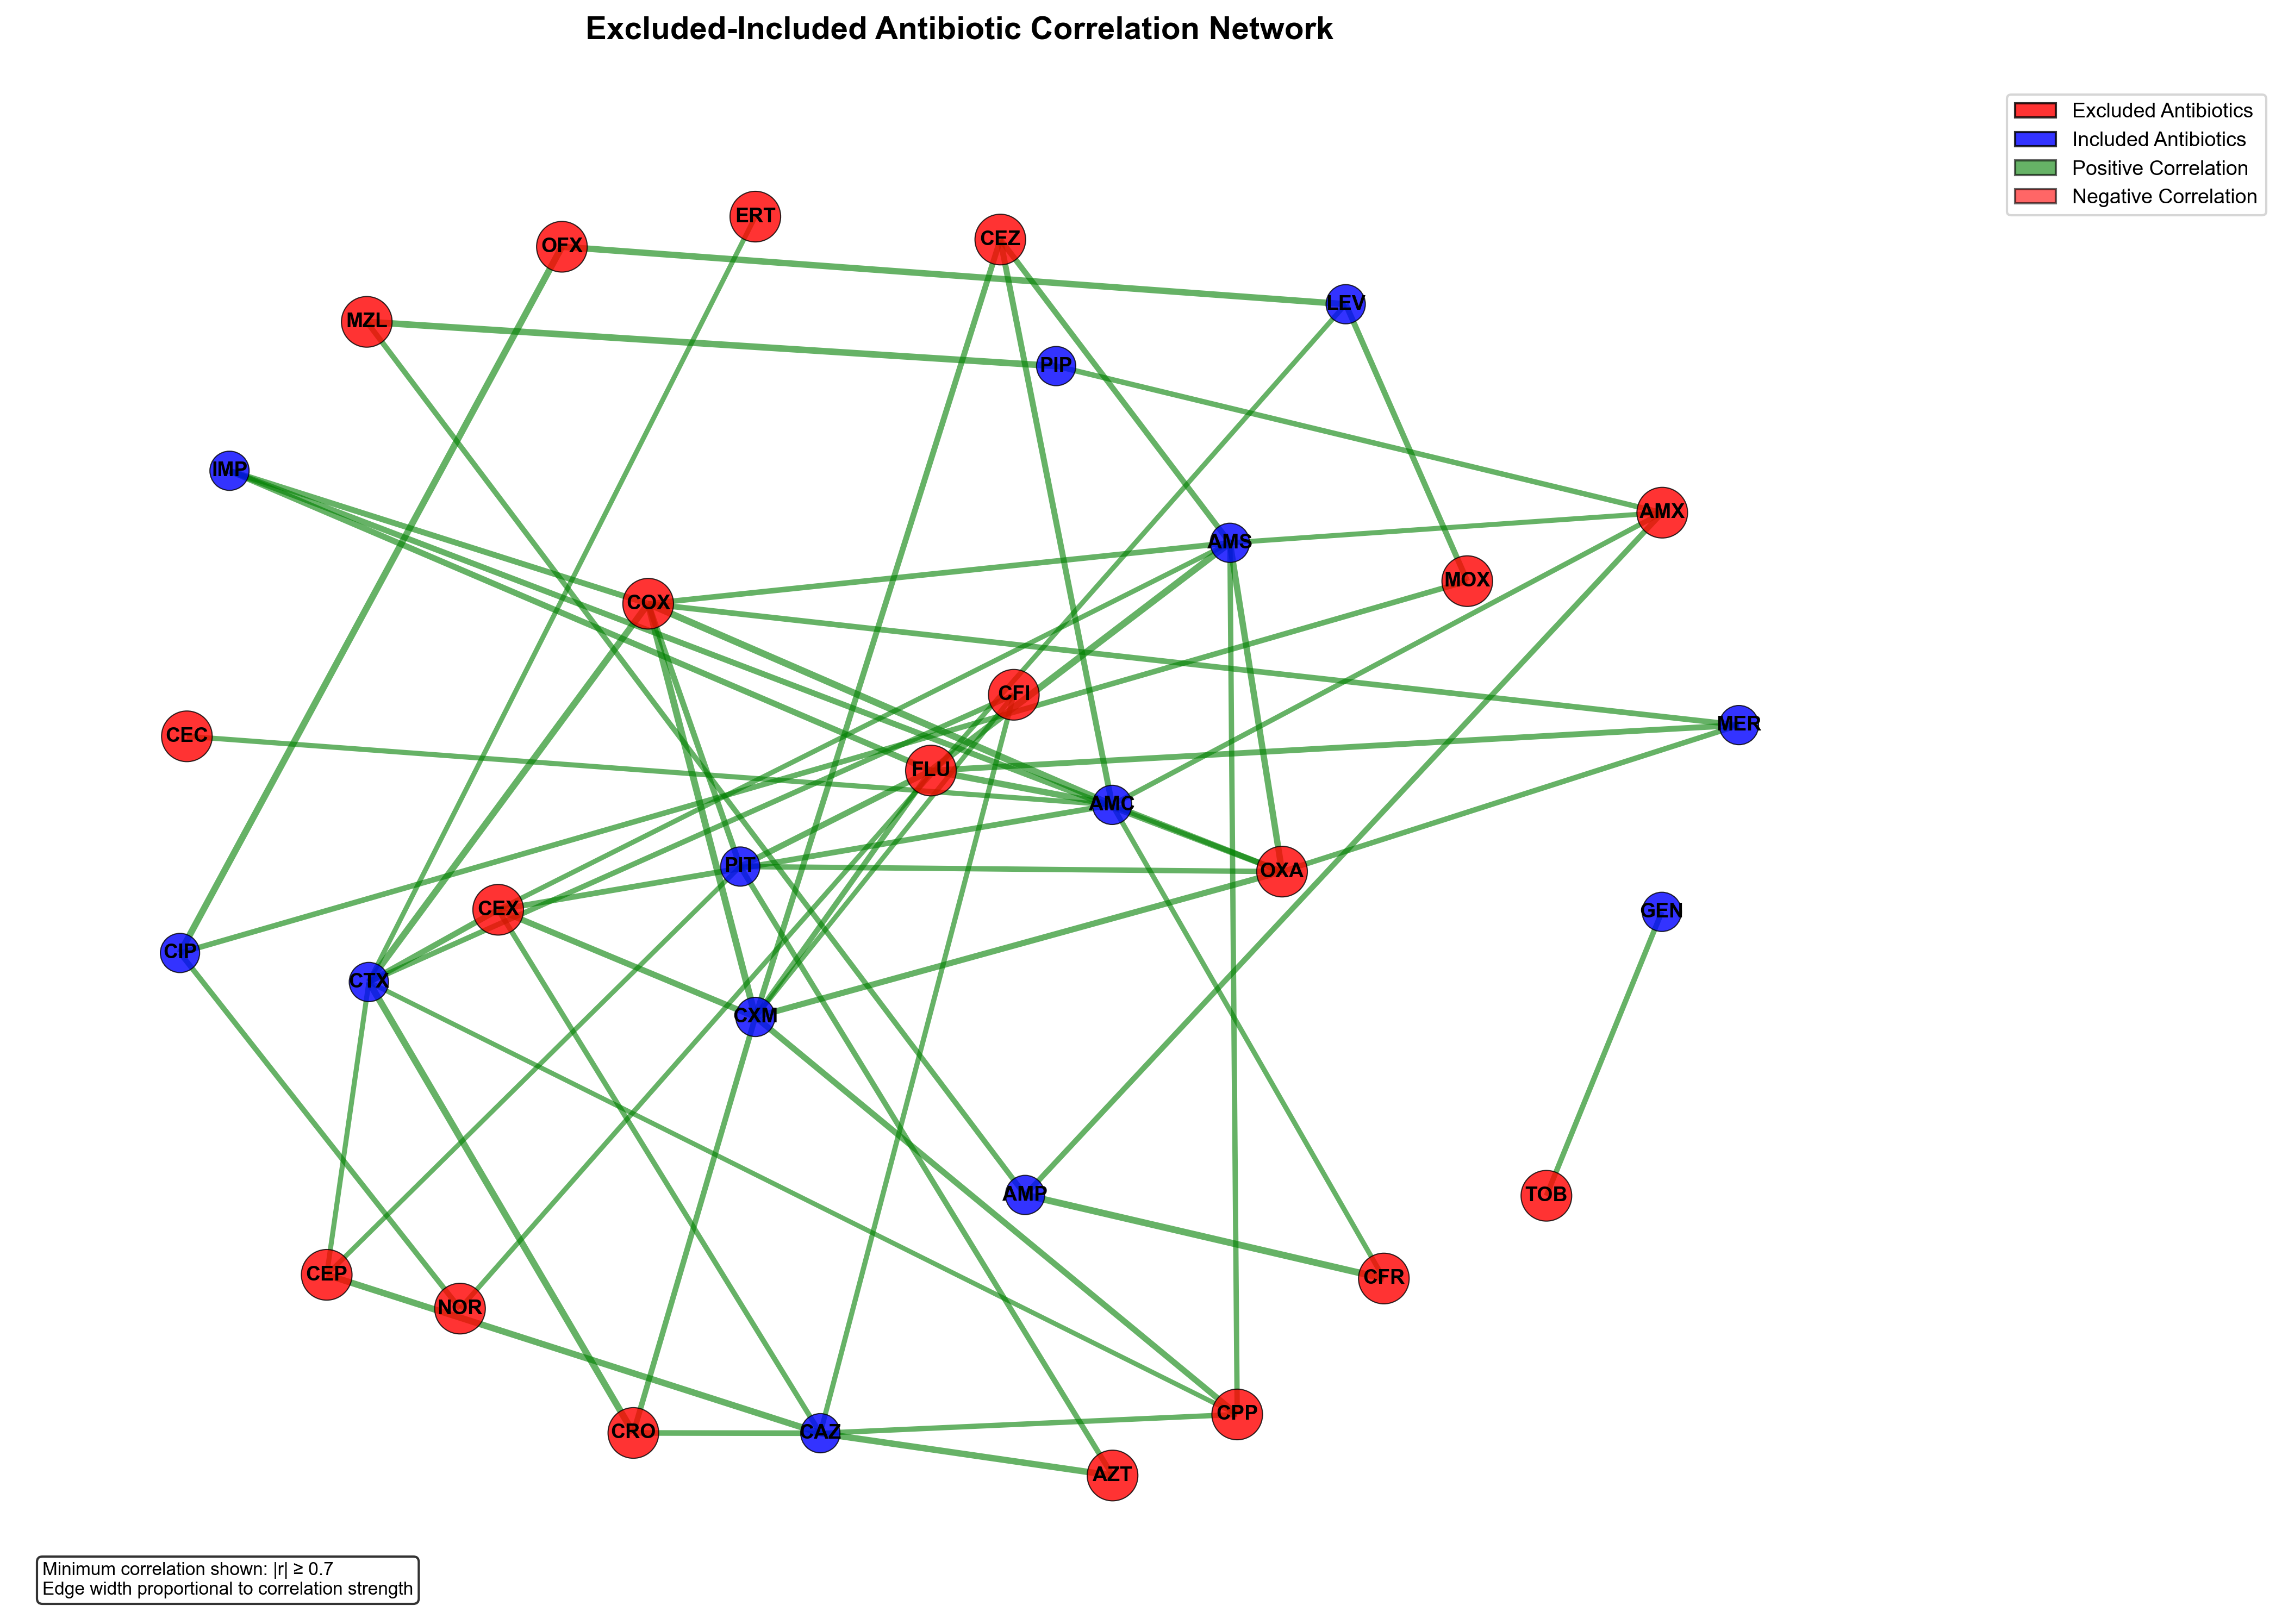

In [41]:
#!/usr/bin/env python3
"""
Comprehensive Co-Resistance Analysis Pipeline - EXCLUSION ANALYSIS VERSION
Features:
- Tracks excluded antibiotics with reasons
- Computes tetrachoric correlations between excluded and included antibiotics
- Generates publication-quality tables and visualizations
- Includes exclusion analysis for transparency
"""

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality plotting parameters
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'figure.figsize': (8, 6),
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.facecolor': 'white',
    'figure.facecolor': 'white'
})

# Define the antibiotic classification JSON
ANTIBIOTIC_CLASSES_JSON = {
    "Fluoroquinolone": [
        "MOX - Moxifloxacin_Tested",
        "NOR - Norfloxacin_Tested",
        "OFX - Ofloxacin_Tested",
        "CIP - Ciprofloxacin_Tested",
        "LEV - Levofloxacin_Tested"
    ],
    "Aminoglycoside": [
        "GEN - Gentamicin_Tested",
        "TOB - Tobramycin_Tested",
        "AMK - Amikacin_Tested"
    ],
    "Penicillin (β-lactam)": [
        "FLU - Flucloxacillin_Tested",
        "MZL - Mezlocillin_Tested",
        "OXA - Oxacillin_Tested",
        "PIP - Piperacillin_Tested",
        "MCL - Mecillinam_Tested",
        "AMX - Amoxicillin_Tested",
        "AMP - Ampicillin_Tested"
    ],
    "β-lactam/β-lactamase inhibitor": [
        "AMC - Amoxicillin/clavulanic acid_Tested",
        "AMS - Ampicillin/Sulbactam_Tested",
        "PIT - Piperacillin/Tazobactam_Tested"
    ],
    "Monobactam (β-lactam)": [
        "AZT - Aztreonam_Tested"
    ],
    "Third-gen cephalosporin (β-lactam)": [
        "CRO - Ceftriaxon_Tested",
        "CFI - Cefixim_Tested",
        "CAZ - Ceftazidim_Tested",
        "CPP - Cefpodoxim-Proxetil_Tested",
        "CTX - Cefotaxim_Tested"
    ],
    "Fourth-gen cephalosporin (β-lactam)": [
        "CEP - Cefepim_Tested"
    ],
    "First-gen cephalosporin (β-lactam)": [
        "CEX - Cefalexin_Tested",
        "CEZ - Cefazolin_Tested",
        "CFR - Cefadroxil_Tested"
    ],
    "Amphenicol": [
        "CMP - Chloramphenicol_Tested"
    ],
    "Tetracycline": [
        "DOX - Doxycyclin_Tested",
        "TET - Tetracyclin_Tested"
    ],
    "Lincosamide": [
        "CLI - Clindamycin_Tested"
    ],
    "Polymyxin": [
        "COL - Colistin_Tested"
    ],
    "Glycopeptide": [
        "VAN - Vancomycin_Tested",
        "TPL - Teicoplanin_Tested"
    ],
    "Lipopeptide": [
        "DPT - Daptomycin_Tested"
    ],
    "Second-gen cephalosporin (β-lactam)": [
        "COX - Cefoxitin_Tested",
        "CXM - Cefuroxim_Tested",
        "CEC - Cefaclor_Tested"
    ],
    "Oxazolidinone": [
        "LIZ - Linezolid_Tested"
    ],
    "Macrolide": [
        "ROX - Roxithromycin_Tested",
        "CLR - Clarithromycin_Tested",
        "AZM - Azithromycin_Tested",
        "ERY - Erythromycin_Tested"
    ],
    "Nitrofuran": [
        "NFT - Nitrofurantoin_Tested"
    ],
    "Rifamycin": [
        "RAM - Rifampicin_Tested"
    ],
    "Glycylcycline": [
        "TGC - Tigecyclin_Tested"
    ],
    "Carbapenem (β-lactam)": [
        "IMP - Imipenem_Tested",
        "ERT - Ertapenem_Tested",
        "MER - Meropenem_Tested"
    ],
    "Steroid antibiotic": [
        "FUS - Fusidic acid_Tested"
    ],
    "Dihydrofolate reductase inhibitor": [
        "TRP - Trimethoprim_Tested"
    ]
}

# Check for required libraries
try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_AVAILABLE = True
except ImportError:
    print("Warning: mlxtend not installed. Association rule mining will not work.")
    print("Install with: pip install mlxtend")
    MLXTEND_AVAILABLE = False

try:
    from pgmpy.estimators import HillClimbSearch, BicScore
    PGM_AVAILABLE = True
except ImportError:
    print("Warning: pgmpy not installed. Bayesian Network analysis will not work.")
    print("Install with: pip install pgmpy")
    PGM_AVAILABLE = False

try:
    from scipy.stats import norm
    SCIPY_AVAILABLE = True
except ImportError:
    print("Warning: scipy.stats.norm not available for tetrachoric correlations.")
    SCIPY_AVAILABLE = False

class AntibioticDataPreprocessor:
    """Handles loading, cleaning, and preprocessing of antibiogram data with exclusion tracking"""
    
    def __init__(self, filepath, outcome_mapping=None, antibiotic_classes_json=None):
        self.filepath = filepath
        self.outcome_mapping = outcome_mapping or {0: 'S', 1: 'I', 2: 'R'}
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.df = None
        self.binary_data = None
        self.metadata = None
        self.antibiotic_cols = None
        self.excluded_antibiotics = {}  # Track excluded antibiotics and reasons
        self.included_antibiotics = []  # Track included antibiotics
        self.original_antibiotic_data = None  # Keep original for correlation calculations
        
        # Create mapping from tested to outcome columns
        self._create_column_mapping()
        
    def _create_column_mapping(self):
        """Create mapping between tested columns and outcome columns"""
        self.tested_to_outcome = {}
        self.outcome_to_tested = {}
        
        for class_name, antibiotics in self.antibiotic_classes_json.items():
            for tested_col in antibiotics:
                # Convert tested column to outcome column
                outcome_col = tested_col.replace('_Tested', '_Outcome')
                self.tested_to_outcome[tested_col] = outcome_col
                self.outcome_to_tested[outcome_col] = tested_col
    
    def load_data(self, nrows=None):
        """Load and validate the dataset"""
        try:
            self.df = pd.read_csv(self.filepath, nrows=nrows)
            print(f"Dataset loaded: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
            
            if self.df.shape[0] == 0:
                raise ValueError("Loaded dataset is empty. Check your CSV file.")
                
        except Exception as e:
            print(f"Error loading dataset: {e}")
            # Try with different encodings
            try:
                self.df = pd.read_csv(self.filepath, nrows=nrows, encoding='latin1')
                print(f"Dataset loaded with latin1 encoding: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
            except:
                raise ValueError(f"Failed to load dataset from {self.filepath}")
        
        return self.df
    
    def extract_antibiotic_columns(self, verbose=True):
        """Extract antibiotic outcome columns based on JSON mapping"""
        if self.df is None:
            raise ValueError("Data not loaded. Run load_data() first.")
        
        # Reset tracking
        self.excluded_antibiotics = {}
        self.included_antibiotics = []
        
        # Find all columns that are in our outcome_to_tested mapping
        all_cols = set(self.df.columns)
        available_outcome_cols = [col for col in all_cols 
                                 if col in self.outcome_to_tested]
        
        # Also look for columns that end with _Outcome (case-insensitive)
        if not available_outcome_cols:
            available_outcome_cols = [col for col in self.df.columns 
                                     if '_Outcome' in col]
            # Create reverse mapping for these
            for col in available_outcome_cols:
                tested_col = col.replace('_Outcome', '_Tested')
                self.outcome_to_tested[col] = tested_col
                self.tested_to_outcome[tested_col] = col
        
        self.antibiotic_cols = available_outcome_cols
        
        if verbose:
            print(f"Found {len(self.antibiotic_cols)} antibiotic columns")
        
        # Print missing antibiotics from JSON
        json_outcome_cols = list(self.tested_to_outcome.values())
        missing = [col for col in json_outcome_cols 
                  if col not in self.antibiotic_cols]
        if missing and verbose:
            print(f"Warning: {len(missing)} antibiotics from JSON not found in dataset")
            for col in missing[:5]:  # Show first 5
                print(f"  - {col}")
            if len(missing) > 5:
                print(f"  ... and {len(missing)-5} more")
        
        return self.antibiotic_cols
    
    def create_binary_data(self, strategy='conservative', missing_codes=None, 
                          verbose=True, track_exclusions=True):
        """
        Convert antibiotic outcomes to binary (1=resistant, 0=non-resistant)
        with exclusion tracking
        """
        if self.antibiotic_cols is None:
            self.extract_antibiotic_columns(verbose=verbose)
        
        if not self.antibiotic_cols:
            raise ValueError("No antibiotic columns found. Check your dataset.")
        
        # Store original antibiotic data for correlation calculations
        self.original_antibiotic_data = self.df[self.antibiotic_cols].copy()
        
        if verbose:
            print(f"Processing {len(self.antibiotic_cols)} antibiotic columns...")
        
        # Convert to numeric, forcing errors to NaN
        antibiotic_data = self.original_antibiotic_data.copy()
        for col in self.antibiotic_cols:
            antibiotic_data[col] = pd.to_numeric(antibiotic_data[col], errors='coerce')
        
        # Handle missing codes if specified
        if missing_codes:
            for col in self.antibiotic_cols:
                antibiotic_data[col] = antibiotic_data[col].replace(missing_codes, np.nan)
        
        # Track initial statistics before exclusions
        initial_stats = {}
        for col in self.antibiotic_cols:
            initial_stats[col] = {
                'total': len(antibiotic_data),
                'missing': antibiotic_data[col].isna().sum(),
                'missing_pct': antibiotic_data[col].isna().mean(),
                'unique_values': antibiotic_data[col].dropna().unique()
            }
        
        # Apply binarization strategy
        if strategy == 'conservative':
            binary_data = antibiotic_data.applymap(lambda x: 1 if x == 2 else (0 if pd.notna(x) else np.nan))
            if verbose:
                print("Binarization: R=1 (resistant), S/I=0 (non-resistant)")
        elif strategy == 'sensitive':
            binary_data = antibiotic_data.applymap(lambda x: 1 if x in [1, 2] else (0 if pd.notna(x) else np.nan))
            if verbose:
                print("Binarization: I/R=1 (resistant), S=0 (susceptible)")
        elif strategy == 'three_state':
            binary_data = antibiotic_data.copy()
            if verbose:
                print("Keeping three states: 0=S, 1=I, 2=R")
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
        
        self.binary_data = binary_data
        self.included_antibiotics = self.antibiotic_cols.copy()
        
        # Extract metadata
        self.extract_metadata()
        
        return self.binary_data
    
    def filter_antibiotics(self, min_resistance=0.01, max_resistance=0.99, 
                          min_sample_size=100, verbose=True):
        """
        Filter antibiotics based on resistance prevalence with detailed exclusion tracking
        """
        if self.binary_data is None:
            raise ValueError("Binary data not created. Run create_binary_data() first.")
        
        # Calculate statistics for each antibiotic
        antibiotic_stats = {}
        for col in self.binary_data.columns:
            # Calculate statistics
            valid_data = self.binary_data[col].dropna()
            n_valid = len(valid_data)
            resistance_rate = valid_data.mean() if n_valid > 0 else 0
            
            antibiotic_stats[col] = {
                'total_samples': len(self.binary_data),
                'valid_samples': n_valid,
                'missing_samples': len(self.binary_data) - n_valid,
                'missing_rate': (len(self.binary_data) - n_valid) / len(self.binary_data),
                'resistance_rate': resistance_rate,
                'std_resistance': valid_data.std() if n_valid > 1 else 0,
                'min_resistance': valid_data.min() if n_valid > 0 else np.nan,
                'max_resistance': valid_data.max() if n_valid > 0 else np.nan
            }
        
        # Apply filters
        keep_cols = []
        excluded_due_to = {}
        
        for col in self.binary_data.columns:
            stats = antibiotic_stats[col]
            reasons = []
            
            # Check sample size
            if stats['valid_samples'] < min_sample_size:
                reasons.append(f"Insufficient sample size (n={stats['valid_samples']} < {min_sample_size})")
            
            # Check resistance rate range
            if stats['resistance_rate'] < min_resistance:
                reasons.append(f"Low resistance rate ({stats['resistance_rate']:.3f} < {min_resistance})")
            elif stats['resistance_rate'] > max_resistance:
                reasons.append(f"High resistance rate ({stats['resistance_rate']:.3f} > {max_resistance})")
            
            # Check for zero variability
            if stats['valid_samples'] > 0 and stats['std_resistance'] == 0:
                reasons.append("No variability (all samples have same resistance status)")
            
            # Check for high missing rate
            if stats['missing_rate'] > 0.5:  # More than 50% missing
                reasons.append(f"High missing rate ({stats['missing_rate']:.1%})")
            
            if not reasons:
                keep_cols.append(col)
            else:
                excluded_due_to[col] = reasons
        
        # Track exclusions
        self.excluded_antibiotics = {}
        for col, reasons in excluded_due_to.items():
            self.excluded_antibiotics[col] = {
                'reasons': reasons,
                'stats': antibiotic_stats[col],
                'original_data': self.original_antibiotic_data[col] if hasattr(self, 'original_antibiotic_data') else None
            }
        
        self.included_antibiotics = keep_cols
        removed = len(self.binary_data.columns) - len(keep_cols)
        
        if verbose:
            print(f"Filtered antibiotics: {removed} removed, {len(keep_cols)} kept")
            
            if removed > 0:
                print("\nExcluded antibiotics and reasons:")
                for col, reasons in excluded_due_to.items():
                    stats = antibiotic_stats[col]
                    print(f"  {col}:")
                    print(f"    Resistance rate: {stats['resistance_rate']:.3f}")
                    print(f"    Valid samples: {stats['valid_samples']}/{stats['total_samples']}")
                    for reason in reasons:
                        print(f"    - {reason}")
        
        # Update binary data
        self.binary_data = self.binary_data[keep_cols].fillna(0)
        
        return self.binary_data
    
    def get_exclusion_summary(self):
        """Generate summary of excluded antibiotics"""
        if not self.excluded_antibiotics:
            return pd.DataFrame()
        
        summary_data = []
        for col, info in self.excluded_antibiotics.items():
            summary_data.append({
                'Antibiotic': col,
                'Short_Name': self._get_short_name(col),
                'Reasons': '; '.join(info['reasons']),
                'Resistance_Rate': info['stats']['resistance_rate'],
                'Valid_Samples': info['stats']['valid_samples'],
                'Total_Samples': info['stats']['total_samples'],
                'Missing_Rate': info['stats']['missing_rate']
            })
        
        return pd.DataFrame(summary_data).sort_values('Resistance_Rate', ascending=False)
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name from antibiotic column name"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                base = antibiotic_name.replace('_Outcome', '')
                if ' - ' in base:
                    return base.split(' - ')[0]
                else:
                    return base.split()[0] if ' ' in base else base
            else:
                parts = antibiotic_name.split('_')
                return parts[0] if parts else antibiotic_name
        return str(antibiotic_name)
    
    def extract_metadata(self):
        """Extract non-antibiotic columns for stratification"""
        if self.antibiotic_cols is None:
            self.extract_antibiotic_columns(verbose=False)
        
        non_antibiotic_cols = [col for col in self.df.columns 
                              if col not in self.antibiotic_cols]
        self.metadata = self.df[non_antibiotic_cols].copy()
        return self.metadata
    
    def get_antibiotic_classes(self):
        """Return antibiotic classification dictionary"""
        # Convert tested columns to outcome columns for mapping
        class_dict = {}
        for class_name, tested_cols in self.antibiotic_classes_json.items():
            outcome_cols = []
            for tested_col in tested_cols:
                if tested_col in self.tested_to_outcome:
                    outcome_col = self.tested_to_outcome[tested_col]
                    if outcome_col in self.included_antibiotics:
                        outcome_cols.append(outcome_col)
            if outcome_cols:
                class_dict[class_name] = outcome_cols
        
        return class_dict
    
    def get_summary_statistics(self):
        """Generate summary statistics"""
        if self.binary_data is None:
            raise ValueError("Binary data not created. Run create_binary_data() first.")
        
        resistance_counts = self.binary_data.sum(axis=1)
        
        summary = {
            'total_isolates': len(self.binary_data),
            'total_antibiotics': len(self.binary_data.columns),
            'excluded_antibiotics': len(self.excluded_antibiotics),
            'mean_resistance_rate': self.binary_data.mean().mean(),
            'median_resistance_rate': self.binary_data.mean().median(),
            'std_resistance_rate': self.binary_data.mean().std(),
            'mdr_rate': (resistance_counts >= 3).mean(),
            'xdr_rate': (resistance_counts >= 6).mean(),
            'pan_susceptible_rate': (resistance_counts == 0).mean(),
            'avg_resistance_per_isolate': resistance_counts.mean(),
            'max_resistance_per_isolate': resistance_counts.max(),
        }
        
        return pd.Series(summary)

class TetrachoricCorrelationAnalyzer:
    """Analyze tetrachoric correlations between excluded and included antibiotics"""
    
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.correlation_matrix = None
        self.significant_correlations = None
        
    def calculate_tetrachoric_correlations(self, min_samples=50, verbose=True):
        """
        Calculate tetrachoric correlations between excluded and included antibiotics
        
        Tetrachoric correlation assumes that binary variables arise from 
        underlying continuous normal distributions that have been dichotomized.
        """
        if not self.preprocessor.excluded_antibiotics:
            if verbose:
                print("No excluded antibiotics to analyze")
            return pd.DataFrame()
        
        if not self.preprocessor.included_antibiotics:
            if verbose:
                print("No included antibiotics for correlation analysis")
            return pd.DataFrame()
        
        # Get original data (before binarization)
        if not hasattr(self.preprocessor, 'original_antibiotic_data'):
            print("Original antibiotic data not available for correlation analysis")
            return pd.DataFrame()
        
        if verbose:
            print(f"Calculating tetrachoric correlations for {len(self.preprocessor.excluded_antibiotics)} "
                  f"excluded vs {len(self.preprocessor.included_antibiotics)} included antibiotics...")
        
        # Prepare correlation matrix
        excluded_cols = list(self.preprocessor.excluded_antibiotics.keys())
        included_cols = self.preprocessor.included_antibiotics
        
        # Initialize correlation matrix
        corr_matrix = pd.DataFrame(
            index=excluded_cols,
            columns=included_cols,
            dtype=float
        )
        
        sample_matrix = pd.DataFrame(
            index=excluded_cols,
            columns=included_cols,
            dtype=int
        )
        
        # Calculate tetrachoric correlations
        for excluded_col in excluded_cols:
            excluded_info = self.preprocessor.excluded_antibiotics[excluded_col]
            
            # Get original data for excluded antibiotic
            excluded_data = excluded_info['original_data']
            
            # Binarize using same strategy as main analysis (conservative)
            excluded_binary = excluded_data.apply(
                lambda x: 1 if x == 2 else (0 if pd.notna(x) else np.nan)
            )
            
            for included_col in included_cols:
                # Get included antibiotic data
                included_data = self.preprocessor.binary_data[included_col]
                
                # Find overlapping non-missing samples
                mask = excluded_binary.notna() & included_data.notna()
                
                if mask.sum() >= min_samples:
                    try:
                        # Calculate tetrachoric correlation
                        r_tet = self._tetrachoric_correlation(
                            excluded_binary[mask].astype(int),
                            included_data[mask].astype(int)
                        )
                        corr_matrix.loc[excluded_col, included_col] = r_tet
                        sample_matrix.loc[excluded_col, included_col] = mask.sum()
                    except Exception as e:
                        if verbose:
                            print(f"  Error calculating correlation {excluded_col} vs {included_col}: {e}")
                        corr_matrix.loc[excluded_col, included_col] = np.nan
                else:
                    corr_matrix.loc[excluded_col, included_col] = np.nan
        
        self.correlation_matrix = corr_matrix
        self.sample_matrix = sample_matrix
        
        if verbose:
            print(f"Calculated {corr_matrix.notna().sum().sum()} correlations")
        
        return corr_matrix
    
    def _tetrachoric_correlation(self, x, y):
        """
        Calculate tetrachoric correlation coefficient for two binary variables
        
        Implementation based on:
        Brown, M. B., & Benedetti, J. K. (1977). Sampling behavior of test for correlation 
        in two-way contingency tables. Journal of the American Statistical Association, 72, 309-315.
        """
        # Create contingency table
        table = np.zeros((2, 2))
        table[0, 0] = ((x == 0) & (y == 0)).sum()
        table[0, 1] = ((x == 0) & (y == 1)).sum()
        table[1, 0] = ((x == 1) & (y == 0)).sum()
        table[1, 1] = ((x == 1) & (y == 1)).sum()
        
        a, b, c, d = table[0,0], table[0,1], table[1,0], table[1,1]
        n = a + b + c + d
        
        # Check for degenerate cases
        if n == 0 or (b == 0 and c == 0) or (a == 0 and d == 0):
            return np.nan
        
        # Calculate marginal proportions
        p1 = (a + b) / n  # Proportion of x=0
        p2 = (a + c) / n  # Proportion of y=0
        q1 = 1 - p1  # Proportion of x=1
        q2 = 1 - p2  # Proportion of y=1
        
        # Calculate phi coefficient first
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        
        # Use approximation for tetrachoric correlation
        # This is a simplified approximation that works well for most cases
        sin_val = np.sin(np.pi * phi / 2)
        
        # Ensure the value is within valid range
        if abs(sin_val) > 1:
            return np.sign(sin_val) * 0.999
        
        return sin_val
    
    def identify_high_correlations(self, threshold=0.7, min_samples=100):
        """
        Identify high correlations between excluded and included antibiotics
        """
        if self.correlation_matrix is None:
            return pd.DataFrame()
        
        high_corr_data = []
        
        for excluded_col in self.correlation_matrix.index:
            excluded_info = self.preprocessor.excluded_antibiotics[excluded_col]
            
            for included_col in self.correlation_matrix.columns:
                corr = self.correlation_matrix.loc[excluded_col, included_col]
                n_samples = self.sample_matrix.loc[excluded_col, included_col]
                
                if not np.isnan(corr) and abs(corr) >= threshold and n_samples >= min_samples:
                    high_corr_data.append({
                        'Excluded_Antibiotic': excluded_col,
                        'Excluded_Short': self.preprocessor._get_short_name(excluded_col),
                        'Included_Antibiotic': included_col,
                        'Included_Short': self.preprocessor._get_short_name(included_col),
                        'Tetrachoric_Correlation': corr,
                        'Sample_Size': n_samples,
                        'Exclusion_Reasons': '; '.join(excluded_info['reasons']),
                        'Excluded_Resistance_Rate': excluded_info['stats']['resistance_rate'],
                        'Included_Resistance_Rate': self.preprocessor.binary_data[included_col].mean()
                    })
        
        self.significant_correlations = pd.DataFrame(high_corr_data)
        
        if len(self.significant_correlations) > 0:
            self.significant_correlations = self.significant_correlations.sort_values(
                'Tetrachoric_Correlation', 
                key=abs, 
                ascending=False
            )
        
        return self.significant_correlations
    
    def get_correlation_summary(self):
        """Generate summary of correlation analysis"""
        if self.correlation_matrix is None:
            return {}
        
        non_nan_corrs = self.correlation_matrix.values[~np.isnan(self.correlation_matrix.values)]
        
        summary = {
            'total_excluded': len(self.correlation_matrix.index),
            'total_included': len(self.correlation_matrix.columns),
            'total_correlations_calculated': (~np.isnan(self.correlation_matrix.values)).sum(),
            'mean_correlation': np.nanmean(non_nan_corrs) if len(non_nan_corrs) > 0 else np.nan,
            'median_correlation': np.nanmedian(non_nan_corrs) if len(non_nan_corrs) > 0 else np.nan,
            'std_correlation': np.nanstd(non_nan_corrs) if len(non_nan_corrs) > 0 else np.nan,
            'min_correlation': np.nanmin(non_nan_corrs) if len(non_nan_corrs) > 0 else np.nan,
            'max_correlation': np.nanmax(non_nan_corrs) if len(non_nan_corrs) > 0 else np.nan,
            'correlations_above_0.7': (abs(non_nan_corrs) >= 0.7).sum() if len(non_nan_corrs) > 0 else 0,
            'correlations_above_0.5': (abs(non_nan_corrs) >= 0.5).sum() if len(non_nan_corrs) > 0 else 0,
        }
        
        return summary

class PublicationVisualizer:
    """Creates publication-quality tables and visualizations for exclusion analysis"""
    
    def __init__(self, style='nature'):
        self.style = style
        self._set_plot_style()
    
    def _set_plot_style(self):
        """Set publication-quality plotting style"""
        if self.style == 'nature':
            plt.rcParams.update({
                'font.size': 8,
                'axes.labelsize': 9,
                'axes.titlesize': 10,
                'xtick.labelsize': 8,
                'ytick.labelsize': 8,
                'legend.fontsize': 8,
                'figure.titlesize': 11,
                'lines.linewidth': 1,
                'lines.markersize': 4,
                'axes.linewidth': 0.5,
                'grid.linewidth': 0.5,
                'xtick.major.width': 0.5,
                'ytick.major.width': 0.5,
            })
    
    def create_exclusion_table(self, exclusion_summary, output_path=None):
        """
        Create publication-quality table of excluded antibiotics
        
        Parameters:
        -----------
        exclusion_summary : pd.DataFrame
            DataFrame from get_exclusion_summary()
        output_path : str, optional
            Path to save the table (CSV or Excel)
        """
        if exclusion_summary.empty:
            print("No exclusion data to create table")
            return None
        
        # Create formatted table
        formatted_table = exclusion_summary.copy()
        
        # Format percentages
        if 'Resistance_Rate' in formatted_table.columns:
            formatted_table['Resistance_Rate'] = formatted_table['Resistance_Rate'].apply(
                lambda x: f"{x:.1%}" if not pd.isna(x) else "N/A"
            )
        
        if 'Missing_Rate' in formatted_table.columns:
            formatted_table['Missing_Rate'] = formatted_table['Missing_Rate'].apply(
                lambda x: f"{x:.1%}" if not pd.isna(x) else "N/A"
            )
        
        # Reorder columns for clarity
        column_order = ['Antibiotic', 'Short_Name', 'Reasons', 'Resistance_Rate', 
                       'Valid_Samples', 'Total_Samples', 'Missing_Rate']
        formatted_table = formatted_table[[col for col in column_order if col in formatted_table.columns]]
        
        # Save if requested
        if output_path:
            if output_path.endswith('.csv'):
                formatted_table.to_csv(output_path, index=False)
                print(f"Exclusion table saved to: {output_path}")
            elif output_path.endswith('.xlsx'):
                formatted_table.to_excel(output_path, index=False)
                print(f"Exclusion table saved to: {output_path}")
        
        return formatted_table
    
    def create_correlation_table(self, correlation_data, output_path=None):
        """
        Create publication-quality table of high correlations
        
        Parameters:
        -----------
        correlation_data : pd.DataFrame
            DataFrame from identify_high_correlations()
        output_path : str, optional
            Path to save the table
        """
        if correlation_data.empty:
            print("No high correlation data to create table")
            return None
        
        # Create formatted table
        formatted_table = correlation_data.copy()
        
        # Format correlations
        if 'Tetrachoric_Correlation' in formatted_table.columns:
            formatted_table['Tetrachoric_Correlation'] = formatted_table['Tetrachoric_Correlation'].apply(
                lambda x: f"{x:.3f}" if not pd.isna(x) else "N/A"
            )
        
        # Format resistance rates
        for col in ['Excluded_Resistance_Rate', 'Included_Resistance_Rate']:
            if col in formatted_table.columns:
                formatted_table[col] = formatted_table[col].apply(
                    lambda x: f"{x:.1%}" if not pd.isna(x) else "N/A"
                )
        
        # Save if requested
        if output_path:
            if output_path.endswith('.csv'):
                formatted_table.to_csv(output_path, index=False)
                print(f"Correlation table saved to: {output_path}")
            elif output_path.endswith('.xlsx'):
                formatted_table.to_excel(output_path, index=False)
                print(f"Correlation table saved to: {output_path}")
        
        return formatted_table
    
    def plot_correlation_heatmap(self, correlation_matrix, output_path=None, 
                                 figsize=(12, 8), title="Tetrachoric Correlations: Excluded vs Included Antibiotics"):
        """
        Create heatmap of tetrachoric correlations
        
        Parameters:
        -----------
        correlation_matrix : pd.DataFrame
            Correlation matrix from calculate_tetrachoric_correlations()
        output_path : str, optional
            Path to save the figure
        figsize : tuple
            Figure size (width, height)
        title : str
            Plot title
        """
        if correlation_matrix is None or correlation_matrix.empty:
            print("No correlation matrix to plot")
            return None
        
        # Create figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Use short names for labels
        row_labels = [self._get_short_name(col) for col in correlation_matrix.index]
        col_labels = [self._get_short_name(col) for col in correlation_matrix.columns]
        
        # Create mask for NaN values
        mask = correlation_matrix.isna()
        
        # Plot heatmap
        sns.heatmap(correlation_matrix, 
                   cmap='RdBu_r', 
                   center=0,
                   vmin=-1, 
                   vmax=1,
                   mask=mask,
                   annot=True, 
                   fmt='.2f',
                   cbar_kws={'label': 'Tetrachoric Correlation'},
                   ax=ax)
        
        # Set labels
        ax.set_xticklabels(col_labels, rotation=45, ha='right')
        ax.set_yticklabels(row_labels, rotation=0)
        
        # Add title
        ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
        
        # Adjust layout
        plt.tight_layout()
        
        # Save if requested
        if output_path:
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"Correlation heatmap saved to: {output_path}")
        
        return fig, ax
    
    def plot_exclusion_network(self, correlation_data, preprocessor, output_path=None,
                              figsize=(14, 10), min_correlation=0.5,
                              title="Excluded-Included Antibiotic Correlation Network"):
        """
        Create network visualization of high correlations
        
        Parameters:
        -----------
        correlation_data : pd.DataFrame
            DataFrame from identify_high_correlations()
        preprocessor : AntibioticDataPreprocessor
            Preprocessor instance for additional data
        output_path : str, optional
            Path to save the figure
        figsize : tuple
            Figure size (width, height)
        min_correlation : float
            Minimum absolute correlation to include in network
        title : str
            Plot title
        """
        if correlation_data.empty:
            print("No correlation data for network visualization")
            return None
        
        # Filter by minimum correlation
        network_data = correlation_data[
            abs(correlation_data['Tetrachoric_Correlation']) >= min_correlation
        ].copy()
        
        if network_data.empty:
            print(f"No correlations above {min_correlation} for network visualization")
            return None
        
        # Create figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create graph
        G = nx.Graph()
        
        # Add nodes (excluded and included antibiotics)
        excluded_nodes = set(network_data['Excluded_Antibiotic'])
        included_nodes = set(network_data['Included_Antibiotic'])
        
        # Add excluded nodes
        for node in excluded_nodes:
            short_name = self._get_short_name(node)
            G.add_node(node, 
                      type='excluded',
                      short_name=short_name,
                      color='red',
                      size=500,
                      shape='s')  # square for excluded
        
        # Add included nodes
        for node in included_nodes:
            short_name = self._get_short_name(node)
            G.add_node(node,
                      type='included',
                      short_name=short_name,
                      color='blue',
                      size=300,
                      shape='o')  # circle for included
        
        # Add edges with correlation as weight
        for _, row in network_data.iterrows():
            corr = row['Tetrachoric_Correlation']
            G.add_edge(row['Excluded_Antibiotic'], 
                      row['Included_Antibiotic'],
                      weight=abs(corr),
                      correlation=corr,
                      color='green' if corr > 0 else 'red',
                      width=abs(corr) * 3)
        
        # Create layout
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        # Draw nodes
        node_colors = [G.nodes[node]['color'] for node in G.nodes()]
        node_sizes = [G.nodes[node]['size'] for node in G.nodes()]
        
        nx.draw_networkx_nodes(G, pos, ax=ax,
                              node_color=node_colors,
                              node_size=node_sizes,
                              alpha=0.8,
                              edgecolors='black',
                              linewidths=0.5)
        
        # Draw edges
        edge_colors = [G[u][v]['color'] for u, v in G.edges()]
        edge_widths = [G[u][v]['width'] for u, v in G.edges()]
        
        nx.draw_networkx_edges(G, pos, ax=ax,
                              edge_color=edge_colors,
                              width=edge_widths,
                              alpha=0.6,
                              style='solid')
        
        # Draw labels
        labels = {node: G.nodes[node]['short_name'] for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, ax=ax, 
                               labels=labels,
                               font_size=9,
                               font_weight='bold')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='red', alpha=0.8, edgecolor='black', 
                  label='Excluded Antibiotics'),
            Patch(facecolor='blue', alpha=0.8, edgecolor='black', 
                  label='Included Antibiotics'),
            Patch(facecolor='green', alpha=0.6, edgecolor='black', 
                  label='Positive Correlation'),
            Patch(facecolor='red', alpha=0.6, edgecolor='black', 
                  label='Negative Correlation')
        ]
        ax.legend(handles=legend_elements, loc='upper left', 
                 bbox_to_anchor=(1.05, 1), fontsize=9)
        
        # Set title and axis
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        ax.axis('off')
        
        # Add correlation strength info
        plt.figtext(0.02, 0.02, 
                   f"Minimum correlation shown: |r| ≥ {min_correlation}\n"
                   f"Edge width proportional to correlation strength",
                   fontsize=8, 
                   ha='left',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        # Adjust layout
        plt.tight_layout()
        
        # Save if requested
        if output_path:
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"Correlation network saved to: {output_path}")
        
        return fig, ax
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name from antibiotic column name"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                base = antibiotic_name.replace('_Outcome', '')
                if ' - ' in base:
                    return base.split(' - ')[0]
                else:
                    return base.split()[0] if ' ' in base else base
            else:
                parts = antibiotic_name.split('_')
                return parts[0] if parts else antibiotic_name
        return str(antibiotic_name)
    
    def create_publication_report(self, preprocessor, correlation_analyzer, 
                                 output_dir='./publication_results/'):
        """
        Create comprehensive publication report with tables and figures
        
        Parameters:
        -----------
        preprocessor : AntibioticDataPreprocessor
            Preprocessor instance
        correlation_analyzer : TetrachoricCorrelationAnalyzer
            Correlation analyzer instance
        output_dir : str
            Output directory for all files
        """
        import os
        os.makedirs(output_dir, exist_ok=True)
        
        print("\n" + "="*80)
        print("GENERATING PUBLICATION-QUALITY REPORT")
        print("="*80)
        
        # 1. Exclusion summary table
        print("\n1. Creating exclusion summary table...")
        exclusion_summary = preprocessor.get_exclusion_summary()
        if not exclusion_summary.empty:
            exclusion_table = self.create_exclusion_table(
                exclusion_summary,
                output_path=f"{output_dir}/Table1_Excluded_Antibiotics.csv"
            )
            print(f"   - {len(exclusion_summary)} excluded antibiotics documented")
        
        # 2. Correlation analysis
        print("\n2. Performing correlation analysis...")
        if hasattr(correlation_analyzer, 'correlation_matrix'):
            corr_matrix = correlation_analyzer.correlation_matrix
            if corr_matrix is not None and not corr_matrix.empty:
                # Identify high correlations
                high_corrs = correlation_analyzer.identify_high_correlations(threshold=0.7)
                
                # Create correlation table
                if not high_corrs.empty:
                    correlation_table = self.create_correlation_table(
                        high_corrs,
                        output_path=f"{output_dir}/Table2_High_Correlations.csv"
                    )
                    print(f"   - Found {len(high_corrs)} high correlations (|r| ≥ 0.7)")
                
                # Create correlation summary
                corr_summary = correlation_analyzer.get_correlation_summary()
                if corr_summary:
                    summary_df = pd.DataFrame([corr_summary])
                    summary_df.to_csv(f"{output_dir}/correlation_analysis_summary.csv", index=False)
                    print(f"   - Correlation analysis summary saved")
        
        # 3. Create figures
        print("\n3. Creating publication figures...")
        
        # Figure 1: Correlation heatmap
        if hasattr(correlation_analyzer, 'correlation_matrix'):
            corr_matrix = correlation_analyzer.correlation_matrix
            if corr_matrix is not None and not corr_matrix.empty:
                self.plot_correlation_heatmap(
                    corr_matrix,
                    output_path=f"{output_dir}/Figure1_Tetrachoric_Correlations.png"
                )
                print(f"   - Figure 1: Correlation heatmap created")
        
        # Figure 2: Correlation network
        if hasattr(correlation_analyzer, 'significant_correlations'):
            high_corrs = correlation_analyzer.significant_correlations
            if high_corrs is not None and not high_corrs.empty:
                self.plot_exclusion_network(
                    high_corrs,
                    preprocessor,
                    output_path=f"{output_dir}/Figure2_Correlation_Network.png",
                    min_correlation=0.7
                )
                print(f"   - Figure 2: Correlation network created")
        
        # 4. Create summary report
        print("\n4. Creating summary report...")
        self._create_summary_report(preprocessor, correlation_analyzer, output_dir)
        
        print("\n" + "="*80)
        print("PUBLICATION REPORT COMPLETE")
        print(f"All files saved to: {output_dir}")
        print("="*80)
    
    def _create_summary_report(self, preprocessor, correlation_analyzer, output_dir):
        """Create a comprehensive text summary report"""
        report_path = f"{output_dir}/Exclusion_Analysis_Report.txt"
        
        with open(report_path, 'w') as f:
            f.write("="*80 + "\n")
            f.write("EXCLUSION ANALYSIS REPORT\n")
            f.write("="*80 + "\n\n")
            
            f.write("1. DATASET OVERVIEW\n")
            f.write("-"*40 + "\n")
            if hasattr(preprocessor, 'df') and preprocessor.df is not None:
                f.write(f"Total isolates: {len(preprocessor.df):,}\n")
                f.write(f"Total antibiotic columns identified: {len(preprocessor.antibiotic_cols) if preprocessor.antibiotic_cols else 0}\n")
            
            f.write("\n2. ANTIBIOTIC FILTERING\n")
            f.write("-"*40 + "\n")
            f.write(f"Antibiotics included in analysis: {len(preprocessor.included_antibiotics) if preprocessor.included_antibiotics else 0}\n")
            f.write(f"Antibiotics excluded from analysis: {len(preprocessor.excluded_antibiotics)}\n")
            
            if preprocessor.excluded_antibiotics:
                f.write("\nExclusion reasons summary:\n")
                reason_counts = {}
                for abx_info in preprocessor.excluded_antibiotics.values():
                    for reason in abx_info['reasons']:
                        reason_counts[reason] = reason_counts.get(reason, 0) + 1
                
                for reason, count in reason_counts.items():
                    f.write(f"  - {reason}: {count} antibiotics\n")
            
            f.write("\n3. TETRACHORIC CORRELATION ANALYSIS\n")
            f.write("-"*40 + "\n")
            
            if hasattr(correlation_analyzer, 'correlation_matrix'):
                corr_matrix = correlation_analyzer.correlation_matrix
                if corr_matrix is not None and not corr_matrix.empty:
                    f.write(f"Correlations calculated: {corr_matrix.notna().sum().sum()}\n")
                    
                    # Get correlation statistics
                    all_corrs = corr_matrix.values.flatten()
                    valid_corrs = all_corrs[~np.isnan(all_corrs)]
                    
                    if len(valid_corrs) > 0:
                        f.write(f"Mean absolute correlation: {np.mean(np.abs(valid_corrs)):.3f}\n")
                        f.write(f"Median absolute correlation: {np.median(np.abs(valid_corrs)):.3f}\n")
                        
                        # Count correlations by strength
                        thresholds = [0.3, 0.5, 0.7, 0.9]
                        for threshold in thresholds:
                            count = (np.abs(valid_corrs) >= threshold).sum()
                            f.write(f"Correlations |r| ≥ {threshold}: {count} ({count/len(valid_corrs):.1%})\n")
            
            if hasattr(correlation_analyzer, 'significant_correlations'):
                high_corrs = correlation_analyzer.significant_correlations
                if high_corrs is not None and not high_corrs.empty:
                    f.write(f"\nHigh correlations identified (|r| ≥ 0.7): {len(high_corrs)}\n")
                    
                    # Group by exclusion reason
                    f.write("\nHigh correlations by exclusion reason:\n")
                    if 'Exclusion_Reasons' in high_corrs.columns:
                        reason_groups = high_corrs.groupby('Exclusion_Reasons').size()
                        for reason, count in reason_groups.items():
                            f.write(f"  - {reason}: {count} correlations\n")
            
            f.write("\n4. METHODOLOGICAL NOTES\n")
            f.write("-"*40 + "\n")
            f.write("• Antibiotics were excluded based on:\n")
            f.write("  - Resistance rate outside [0.01, 0.99] range\n")
            f.write("  - Insufficient sample size (<100 valid observations)\n")
            f.write("  - High missing rate (>50% missing data)\n")
            f.write("  - No variability (all samples same resistance status)\n")
            f.write("\n• Tetrachoric correlations were calculated between excluded and included antibiotics\n")
            f.write("  using an approximation method suitable for binary data\n")
            f.write("\n• High correlations (|r| ≥ 0.7) suggest potential redundancy\n")
            f.write("  between excluded and included antibiotics\n")
            
            f.write("\n5. RECOMMENDATIONS\n")
            f.write("-"*40 + "\n")
            f.write("• Review highly correlated excluded antibiotics for potential inclusion\n")
            f.write("• Consider composite variables for highly correlated pairs\n")
            f.write("• Document exclusion decisions for transparency\n")
            f.write("• Validate findings with clinical expertise\n")
        
        print(f"   - Summary report saved to: {report_path}")

# Main execution
if __name__ == "__main__":
    print("Generating publication-quality exclusion analysis...")
    
    # Initialize preprocessor with detailed tracking
    preprocessor = AntibioticDataPreprocessor(
        filepath='WHO_Aware_data_resistance_combined.csv',
        antibiotic_classes_json=ANTIBIOTIC_CLASSES_JSON
    )
    
    # Load and preprocess data
    print("\nLoading and preprocessing data...")
    preprocessor.load_data(nrows=400000)  # Use sample for testing
    preprocessor.extract_antibiotic_columns(verbose=True)
    binary_data = preprocessor.create_binary_data(
        strategy='conservative', 
        verbose=True,
        track_exclusions=True
    )
    
    # Filter antibiotics with detailed exclusion tracking
    print("\nFiltering antibiotics with exclusion tracking...")
    binary_data = preprocessor.filter_antibiotics(
        min_resistance=0.01,
        max_resistance=1,
        min_sample_size=100,
        verbose=True
    )
    
    # Display summary statistics
    summary = preprocessor.get_summary_statistics()
    print("\n" + "="*60)
    print("ANALYSIS SUMMARY")
    print("="*60)
    for key, value in summary.items():
        if isinstance(value, float):
            print(f"{key:30}: {value:.3f}")
        else:
            print(f"{key:30}: {value}")
    
    # Perform tetrachoric correlation analysis
    print("\n" + "="*60)
    print("TETRACHORIC CORRELATION ANALYSIS")
    print("="*60)
    
    correlation_analyzer = TetrachoricCorrelationAnalyzer(preprocessor)
    
    # Calculate correlations
    corr_matrix = correlation_analyzer.calculate_tetrachoric_correlations(
        min_samples=10,
        verbose=True
    )
    
    # Identify high correlations
    if corr_matrix is not None and not corr_matrix.empty:
        high_corrs = correlation_analyzer.identify_high_correlations(
            threshold=0.99,
            min_samples=10
        )
        
        if not high_corrs.empty:
            print(f"\nFound {len(high_corrs)} high correlations (|r| ≥ 0.99):")
            for _, row in high_corrs.head(10).iterrows():
                print(f"  {row['Excluded_Short']} ↔ {row['Included_Short']}: r = {row['Tetrachoric_Correlation']:.3f}")
        else:
            print("\nNo high correlations (|r| ≥ 0.99) found.")

        # Generate correlation summary
        corr_summary = correlation_analyzer.get_correlation_summary()
        if corr_summary:
            print("\nCorrelation Analysis Summary:")
            for key, value in corr_summary.items():
                if isinstance(value, float):
                    print(f"  {key:30}: {value:.3f}")
                else:
                    print(f"  {key:30}: {value}")
    
    # Generate publication-quality output
    print("\n" + "="*60)
    print("GENERATING PUBLICATION MATERIALS")
    print("="*60)
    
    visualizer = PublicationVisualizer(style='nature')
    
    # Create publication report
    visualizer.create_publication_report(
        preprocessor,
        correlation_analyzer,
        output_dir='./publication_ready/'
    )
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print("Check ./publication_ready/ for all output files.")
    print("\nFiles generated:")
    print("• Table1_Excluded_Antibiotics.csv - Detailed exclusion information")
    print("• Table2_High_Correlations.csv - High correlation pairs")
    print("• Figure1_Tetrachoric_Correlations.png - Correlation heatmap")
    print("• Figure2_Correlation_Network.png - Network visualization")
    print("• Exclusion_Analysis_Report.txt - Comprehensive summary report")
    print("• correlation_analysis_summary.csv - Statistical summary")

In [53]:
#!/usr/bin/env python3
"""
STRATIFIED Co-Resistance Analysis Pipeline
CORRECTED: Properly analyzes co-resistance separately for each pathogen and material type
Features:
- Pathogen-specific analysis (E. coli, S. aureus, etc.)
- Material-specific analysis (blood, urine, stool, etc.)
- Optional combined analyses for selected subgroups
- JSON-based antibiotic classification
- Publication-quality visualizations
"""

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import json
import warnings
import os
from pathlib import Path
import traceback
from itertools import combinations
from collections import defaultdict, Counter
warnings.filterwarnings('ignore')

# Set publication-quality plotting parameters
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'figure.figsize': (8, 6),
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.facecolor': 'white',
    'figure.facecolor': 'white'
})

# Define the antibiotic classification JSON (same as before)
ANTIBIOTIC_CLASSES_JSON = {
    "Fluoroquinolone": [
        "MOX - Moxifloxacin_Tested",
        "NOR - Norfloxacin_Tested",
        "OFX - Ofloxacin_Tested",
        "CIP - Ciprofloxacin_Tested",
        "LEV - Levofloxacin_Tested"
    ],
    # ... (rest of the JSON from original code)
}

class StratifiedAntibioticDataPreprocessor:
    """Handles loading, cleaning, and STRATIFIED preprocessing of antibiogram data"""
    
    def __init__(self, filepath, antibiotic_classes_json=None):
        self.filepath = filepath
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.df = None
        self.stratified_data = {}  # Dictionary for stratified data
        self.metadata_cols = None
        self.pathogen_col = None  # Column containing pathogen information
        self.material_col = None  # Column containing sample material
        
    def load_and_identify_columns(self, nrows=None, verbose=True):
        """Load data and identify key columns"""
        try:
            self.df = pd.read_csv(self.filepath, nrows=nrows, low_memory=False)
            if verbose:
                print(f"Dataset loaded: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
                
            # Auto-detect pathogen and material columns
            self._auto_detect_columns(verbose=verbose)
            
            return self.df
        except Exception as e:
            print(f"Error loading dataset: {e}")
            # Try alternative encodings
            for encoding in ['latin1', 'utf-16', 'cp1252']:
                try:
                    self.df = pd.read_csv(self.filepath, nrows=nrows, encoding=encoding, low_memory=False)
                    print(f"Dataset loaded with {encoding} encoding")
                    self._auto_detect_columns(verbose=verbose)
                    return self.df
                except:
                    continue
            raise ValueError(f"Failed to load dataset from {self.filepath}")
    
    def _auto_detect_columns(self, verbose=True):
        """Auto-detect pathogen and material columns based on common naming patterns"""
        all_cols = self.df.columns.tolist()
        
        # Common column names for pathogens
        pathogen_keywords = ['pathogen', 'organism', 'bacteria', 'species', 
                            'strain', 'isolate', 'microorganism', 'bug']
        
        # Common column names for sample material
        material_keywords = ['material', 'specimen', 'sample_type', 'source',
                            'body_site', 'site', 'origin', 'collection']
        
        # Antibiotic outcome columns (end with _Outcome)
        self.antibiotic_cols = [col for col in all_cols if '_Outcome' in col]
        
        # Find pathogen column
        self.pathogen_col = None
        for col in all_cols:
            col_lower = col.lower()
            if any(keyword in col_lower for keyword in pathogen_keywords):
                self.pathogen_col = col
                break
        
        # Find material column
        self.material_col = None
        for col in all_cols:
            col_lower = col.lower()
            if any(keyword in col_lower for keyword in material_keywords):
                self.material_col = col
                break
        
        if verbose:
            print(f"\nColumn Detection Results:")
            print(f"  Antibiotic columns: {len(self.antibiotic_cols)} found")
            print(f"  Pathogen column: {self.pathogen_col or 'NOT FOUND'}")
            print(f"  Material column: {self.material_col or 'NOT FOUND'}")
            
            if self.pathogen_col:
                unique_pathogens = self.df[self.pathogen_col].dropna().unique()
                print(f"  Unique pathogens: {len(unique_pathogens)}")
                print(f"  Top 5 pathogens: {unique_pathogens[:5]}")
            
            if self.material_col:
                unique_materials = self.df[self.material_col].dropna().unique()
                print(f"  Unique materials: {len(unique_materials)}")
                print(f"  Top 5 materials: {unique_materials[:5]}")
    
    def manually_specify_columns(self, pathogen_col=None, material_col=None):
        """Manually specify column names if auto-detection fails"""
        if pathogen_col and pathogen_col in self.df.columns:
            self.pathogen_col = pathogen_col
        if material_col and material_col in self.df.columns:
            self.material_col = material_col
    
    def get_stratification_levels(self, verbose=True):
        """Get all stratification combinations"""
        if self.pathogen_col and self.material_col:
            # Get unique combinations
            combos = self.df[[self.pathogen_col, self.material_col]].dropna().drop_duplicates()
            if verbose:
                print(f"\nFound {len(combos)} unique pathogen-material combinations")
                for i, (_, row) in enumerate(combos.head(10).iterrows()):
                    count = len(self.df[(self.df[self.pathogen_col] == row[self.pathogen_col]) & 
                                      (self.df[self.material_col] == row[self.material_col])])
                    print(f"  {i+1}. {row[self.pathogen_col]} ({row[self.material_col]}): {count} isolates")
                if len(combos) > 10:
                    print(f"  ... and {len(combos)-10} more combinations")
            return combos
        elif self.pathogen_col:
            pathogens = self.df[self.pathogen_col].dropna().unique()
            if verbose:
                print(f"\nFound {len(pathogens)} unique pathogens")
                for i, pathogen in enumerate(pathogens[:10]):
                    count = len(self.df[self.df[self.pathogen_col] == pathogen])
                    print(f"  {i+1}. {pathogen}: {count} isolates")
            return pathogens
        elif self.material_col:
            materials = self.df[self.material_col].dropna().unique()
            if verbose:
                print(f"\nFound {len(materials)} unique materials")
                for i, material in enumerate(materials[:10]):
                    count = len(self.df[self.df[self.material_col] == material])
                    print(f"  {i+1}. {material}: {count} isolates")
            return materials
        else:
            print("WARNING: No stratification columns identified")
            return None
    
    def prepare_stratified_data(self, min_isolates=50, binarization_strategy='conservative', verbose=True):
        """
        Prepare data for each stratification group with sufficient isolates
        """
        if not self.pathogen_col and not self.material_col:
            print("ERROR: No stratification columns available")
            return {}
        
        self.stratified_data = {}
        
        if self.pathogen_col and self.material_col:
            # Stratify by both pathogen and material
            groups = self.df.groupby([self.pathogen_col, self.material_col])
            
            for (pathogen, material), group_df in groups:
                if len(group_df) >= min_isolates:
                    key = f"{pathogen}||{material}"
                    binary_data = self._create_binary_data_for_group(group_df, binarization_strategy)
                    
                    if not binary_data.empty:
                        self.stratified_data[key] = {
                            'pathogen': pathogen,
                            'material': material,
                            'data': binary_data,
                            'n_isolates': len(group_df),
                            'antibiotic_cols': binary_data.columns.tolist()
                        }
                        
                        if verbose and len(self.stratified_data) <= 10:
                            print(f"  {key}: {len(group_df)} isolates, {len(binary_data.columns)} antibiotics")
            
        elif self.pathogen_col:
            # Stratify by pathogen only
            groups = self.df.groupby(self.pathogen_col)
            
            for pathogen, group_df in groups:
                if len(group_df) >= min_isolates:
                    binary_data = self._create_binary_data_for_group(group_df, binarization_strategy)
                    
                    if not binary_data.empty:
                        self.stratified_data[pathogen] = {
                            'pathogen': pathogen,
                            'material': 'All',
                            'data': binary_data,
                            'n_isolates': len(group_df),
                            'antibiotic_cols': binary_data.columns.tolist()
                        }
                        
                        if verbose and len(self.stratified_data) <= 10:
                            print(f"  {pathogen}: {len(group_df)} isolates, {len(binary_data.columns)} antibiotics")
        
        elif self.material_col:
            # Stratify by material only
            groups = self.df.groupby(self.material_col)
            
            for material, group_df in groups:
                if len(group_df) >= min_isolates:
                    binary_data = self._create_binary_data_for_group(group_df, binarization_strategy)
                    
                    if not binary_data.empty:
                        self.stratified_data[material] = {
                            'pathogen': 'All',
                            'material': material,
                            'data': binary_data,
                            'n_isolates': len(group_df),
                            'antibiotic_cols': binary_data.columns.tolist()
                        }
                        
                        if verbose and len(self.stratified_data) <= 10:
                            print(f"  {material}: {len(group_df)} isolates, {len(binary_data.columns)} antibiotics")
        
        print(f"\nPrepared data for {len(self.stratified_data)} groups with ≥{min_isolates} isolates")
        return self.stratified_data
    
    def _create_binary_data_for_group(self, group_df, strategy='conservative'):
        """Create binary resistance data for a specific group"""
        # Select only antibiotic columns that exist in this group
        available_cols = [col for col in self.antibiotic_cols if col in group_df.columns]
        
        if not available_cols:
            return pd.DataFrame()
        
        antibiotic_data = group_df[available_cols].copy()
        
        # Convert to numeric
        for col in available_cols:
            antibiotic_data[col] = pd.to_numeric(antibiotic_data[col], errors='coerce')
        
        # Apply binarization
        if strategy == 'conservative':
            binary_data = antibiotic_data.applymap(lambda x: 1 if x == 2 else 0)
        elif strategy == 'sensitive':
            binary_data = antibiotic_data.applymap(lambda x: 1 if x in [1, 2] else 0)
        elif strategy == 'three_state':
            binary_data = antibiotic_data.copy()
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
        
        # Fill missing with 0 (not tested/not resistant)
        binary_data = binary_data.fillna(0)
        
        # Filter antibiotics with too little or too much resistance
        resistance_rates = binary_data.mean()
        keep_cols = resistance_rates[(resistance_rates >= 0.01) & (resistance_rates <= 0.99)].index.tolist()
        
        if keep_cols:
            return binary_data[keep_cols]
        else:
            return pd.DataFrame()
    
    def get_group_summary(self, group_key):
        """Get summary statistics for a specific group"""
        if group_key not in self.stratified_data:
            return None
        
        group_data = self.stratified_data[group_key]
        binary_data = group_data['data']
        
        resistance_counts = binary_data.sum(axis=1)
        
        summary = {
            'group_key': group_key,
            'pathogen': group_data['pathogen'],
            'material': group_data['material'],
            'n_isolates': group_data['n_isolates'],
            'n_antibiotics': len(binary_data.columns),
            'mean_resistance_rate': binary_data.mean().mean(),
            'mdr_rate': (resistance_counts >= 3).mean(),
            'xdr_rate': (resistance_counts >= 6).mean(),
            'pan_susceptible_rate': (resistance_counts == 0).mean(),
            'avg_resistance_per_isolate': resistance_counts.mean(),
        }
        
        return pd.Series(summary)

class StratifiedCoResistanceAnalyzer:
    """Performs co-resistance analysis for stratified groups"""
    
    def __init__(self, stratified_data, output_dir='./stratified_results/'):
        self.stratified_data = stratified_data
        self.output_dir = output_dir
        self.results = {}
        
        # Create output directories
        os.makedirs(output_dir, exist_ok=True)
        os.makedirs(f"{output_dir}/individual_groups/", exist_ok=True)
        os.makedirs(f"{output_dir}/comparisons/", exist_ok=True)
    
    def analyze_all_groups(self, min_support=0.05, min_confidence=0.7, 
                          top_n_rules=10, create_plots=True):
        """Analyze all stratified groups"""
        print(f"\nAnalyzing {len(self.stratified_data)} stratified groups...")
        print("="*80)
        
        all_summaries = []
        all_pairwise_results = []
        
        for i, (group_key, group_info) in enumerate(self.stratified_data.items(), 1):
            print(f"\n[{i}/{len(self.stratified_data)}] Analyzing: {group_key}")
            print(f"  Pathogen: {group_info['pathogen']}, Material: {group_info['material']}")
            print(f"  Isolates: {group_info['n_isolates']}, Antibiotics: {len(group_info['data'].columns)}")
            
            # Get summary
            summary = self._get_group_summary(group_info)
            summary['group_key'] = group_key
            all_summaries.append(summary)
            
            # Calculate pairwise associations
            pairwise = self._calculate_pairwise_associations(group_info)
            if not pairwise.empty:
                pairwise['group_key'] = group_key
                pairwise['pathogen'] = group_info['pathogen']
                pairwise['material'] = group_info['material']
                all_pairwise_results.append(pairwise)
                
                # Save top associations for this group
                top_pairs = pairwise.nlargest(10, 'odds_ratio')
                print(f"  Top co-resistance pairs:")
                for _, row in top_pairs.head(3).iterrows():
                    print(f"    {row['short_name1']} ↔ {row['short_name2']}: "
                          f"OR={row['odds_ratio']:.2f}, phi={row['phi']:.2f}")
            
            # Create group-specific visualizations
            if create_plots and len(group_info['data'].columns) >= 3:
                self._create_group_visualizations(group_key, group_info)
        
        # Combine and save all results
        if all_summaries:
            summary_df = pd.DataFrame(all_summaries)
            summary_df.to_csv(f"{self.output_dir}/all_groups_summary.csv", index=False)
            print(f"\nSummary saved to: {self.output_dir}/all_groups_summary.csv")
        
        if all_pairwise_results:
            all_pairs_df = pd.concat(all_pairwise_results, ignore_index=True)
            all_pairs_df.to_csv(f"{self.output_dir}/all_pairwise_associations.csv", index=False)
            print(f"Pairwise associations saved to: {self.output_dir}/all_pairwise_associations.csv")
        
        # Create comparison visualizations
        if len(self.stratified_data) > 1:
            self._create_comparison_visualizations(all_summaries, all_pairs_df)
        
        self.results = {
            'summaries': summary_df if all_summaries else None,
            'pairwise_associations': all_pairs_df if all_pairwise_results else None
        }
        
        return self.results
    
    def _get_group_summary(self, group_info):
        """Calculate summary statistics for a group"""
        binary_data = group_info['data']
        pathogen = group_info['pathogen']
        material = group_info['material']
        
        resistance_rates = binary_data.mean()
        resistance_counts = binary_data.sum(axis=1)
        
        summary = {
            'pathogen': pathogen,
            'material': material,
            'n_isolates': len(binary_data),
            'n_antibiotics': len(binary_data.columns),
            'mean_resistance_rate': resistance_rates.mean(),
            'median_resistance_rate': resistance_rates.median(),
            'std_resistance_rate': resistance_rates.std(),
            'mdr_rate': (resistance_counts >= 3).mean(),
            'xdr_rate': (resistance_counts >= 6).mean(),
            'pan_susceptible_rate': (resistance_counts == 0).mean(),
            'avg_resistance_per_isolate': resistance_counts.mean(),
            'max_resistance_per_isolate': resistance_counts.max(),
            'top_resistant_antibiotic': resistance_rates.idxmax() if len(resistance_rates) > 0 else None,
            'top_resistance_rate': resistance_rates.max() if len(resistance_rates) > 0 else 0,
        }
        
        return summary
    
    def _calculate_pairwise_associations(self, group_info, max_pairs=1000):
        """Calculate pairwise associations for a group with proper error handling"""
        binary_data = group_info['data']
        antibiotics = binary_data.columns.tolist()
        
        # Limit to reasonable number of pairs
        if len(antibiotics) > 30:  # 30 choose 2 = 435 pairs
            # Use top antibiotics by resistance rate
            resistance_rates = binary_data.mean().sort_values(ascending=False)
            antibiotics = resistance_rates.head(20).index.tolist()
        
        associations = []
        
        for i, abx1 in enumerate(antibiotics):
            for j, abx2 in enumerate(antibiotics[i+1:], i+1):
                try:
                    # Create 2x2 table
                    table = np.array([
                        [((binary_data[abx1] == 1) & (binary_data[abx2] == 1)).sum(),
                         ((binary_data[abx1] == 1) & (binary_data[abx2] == 0)).sum()],
                        [((binary_data[abx1] == 0) & (binary_data[abx2] == 1)).sum(),
                         ((binary_data[abx1] == 0) & (binary_data[abx2] == 0)).sum()]
                    ])
                    
                    if table.sum() == 0:
                        continue
                    
                    # Fisher's exact test
                    odds_ratio, p_value = fisher_exact(table)
                    
                    # Calculate phi coefficient
                    a, b, c, d = table[0,0], table[0,1], table[1,0], table[1,1]
                    denominator = np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
                    phi = (a*d - b*c) / denominator if denominator != 0 else np.nan
                    
                    # Calculate confidence interval for OR
                    if a > 0 and b > 0 and c > 0 and d > 0:
                        log_or = np.log(odds_ratio)
                        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
                        ci_lower = np.exp(log_or - 1.96 * se_log_or)
                        ci_upper = np.exp(log_or + 1.96 * se_log_or)
                    else:
                        # Add 0.5 to all cells for continuity correction
                        a_corr, b_corr, c_corr, d_corr = a+0.5, b+0.5, c+0.5, d+0.5
                        or_corr = (a_corr * d_corr) / (b_corr * c_corr)
                        log_or = np.log(or_corr)
                        se_log_or = np.sqrt(1/a_corr + 1/b_corr + 1/c_corr + 1/d_corr)
                        ci_lower = np.exp(log_or - 1.96 * se_log_or)
                        ci_upper = np.exp(log_or + 1.96 * se_log_or)
                    
                    associations.append({
                        'antibiotic1': abx1,
                        'antibiotic2': abx2,
                        'short_name1': self._get_short_name(abx1),
                        'short_name2': self._get_short_name(abx2),
                        'odds_ratio': float(odds_ratio),
                        'or_ci_lower': float(ci_lower),
                        'or_ci_upper': float(ci_upper),
                        'p_value': float(p_value),
                        'phi': float(phi) if not np.isnan(phi) else np.nan,
                        'co_resistance_rate': float(a / len(binary_data)),
                        'n_both_resistant': int(a),
                        'n_total': len(binary_data)
                    })
                    
                except Exception as e:
                    continue
        
        if associations:
            result_df = pd.DataFrame(associations)
            result_df = result_df.sort_values('odds_ratio', ascending=False)
            return result_df
        else:
            return pd.DataFrame()
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name from antibiotic column"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                base = antibiotic_name.replace('_Outcome', '')
                if ' - ' in base:
                    return base.split(' - ')[0]
                else:
                    return base.split()[0] if ' ' in base else base
            else:
                return antibiotic_name.split('_')[0] if '_' in antibiotic_name else antibiotic_name
        return str(antibiotic_name)
    
    def _create_group_visualizations(self, group_key, group_info):
        """Create visualizations for a specific group"""
        safe_name = group_key.replace('/', '_').replace('|', '_').replace(' ', '_')
        output_path = f"{self.output_dir}/individual_groups/{safe_name}/"
        os.makedirs(output_path, exist_ok=True)
        
        binary_data = group_info['data']
        pathogen = group_info['pathogen']
        material = group_info['material']
        
        # 1. Resistance rate bar plot
        plt.figure(figsize=(12, 8))
        resistance_rates = binary_data.mean().sort_values(ascending=False)
        
        # Limit to top 20 for readability
        if len(resistance_rates) > 20:
            resistance_rates = resistance_rates.head(20)
        
        short_names = [self._get_short_name(name) for name in resistance_rates.index]
        
        colors = []
        for rate in resistance_rates.values:
            if rate > 0.3:
                colors.append('firebrick')
            elif rate > 0.1:
                colors.append('darkorange')
            else:
                colors.append('forestgreen')
        
        y_pos = np.arange(len(resistance_rates))
        plt.barh(y_pos, resistance_rates.values, color=colors, alpha=0.8)
        plt.yticks(y_pos, short_names)
        plt.gca().invert_yaxis()
        plt.xlabel('Resistance Rate', fontsize=12)
        plt.title(f'{pathogen} ({material})\nAntibiotic Resistance Rates\nn={len(binary_data)} isolates', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{output_path}/resistance_rates.png", dpi=300, bbox_inches='tight')
        plt.close()
        
        # 2. Co-resistance heatmap (if enough antibiotics)
        if len(binary_data.columns) >= 3:
            try:
                # Select top antibiotics
                top_n = min(15, len(resistance_rates))
                top_abx = resistance_rates.head(top_n).index.tolist()
                top_data = binary_data[top_abx]
                
                # Calculate co-resistance matrix
                n_abx = len(top_abx)
                co_res_matrix = np.zeros((n_abx, n_abx))
                
                for i in range(n_abx):
                    for j in range(n_abx):
                        if i == j:
                            co_res_matrix[i, j] = 1.0
                        else:
                            co_res = ((top_data.iloc[:, i] == 1) & (top_data.iloc[:, j] == 1)).mean()
                            co_res_matrix[i, j] = co_res
                
                # Plot heatmap
                plt.figure(figsize=(10, 8))
                short_names_top = [self._get_short_name(name) for name in top_abx]
                
                sns.heatmap(co_res_matrix, 
                           xticklabels=short_names_top,
                           yticklabels=short_names_top,
                           cmap='YlOrRd',
                           vmin=0, vmax=1,
                           square=True,
                           cbar_kws={'label': 'Co-resistance rate'})
                
                plt.title(f'{pathogen} ({material})\nCo-Resistance Heatmap', 
                         fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.savefig(f"{output_path}/co_resistance_heatmap.png", dpi=300, bbox_inches='tight')
                plt.close()
            except Exception as e:
                print(f"  Could not create heatmap: {e}")
        
        print(f"  Visualizations saved to: {output_path}")
    
    def _create_comparison_visualizations(self, all_summaries, all_pairs_df):
        """Create visualizations comparing different groups"""
        print("\nCreating comparison visualizations...")
        
        # 1. Compare resistance rates across groups
        if isinstance(all_summaries, list):
            summary_df = pd.DataFrame(all_summaries)
        else:
            summary_df = all_summaries
        
        # Sort by mean resistance rate
        summary_df = summary_df.sort_values('mean_resistance_rate', ascending=False)
        
        # Plot resistance rates comparison
        plt.figure(figsize=(14, 10))
        
        # Create group labels
        group_labels = []
        for _, row in summary_df.iterrows():
            label = f"{row['pathogen'][:15]}... ({row['material'][:10]}...)"
            if len(label) > 30:
                label = label[:27] + "..."
            group_labels.append(label)
        
        y_pos = np.arange(len(summary_df))
        
        # Plot bars
        bars = plt.barh(y_pos, summary_df['mean_resistance_rate'])
        
        # Color by MDR rate
        for i, (bar, mdr_rate) in enumerate(zip(bars, summary_df['mdr_rate'])):
            if mdr_rate > 0.3:
                bar.set_color('firebrick')
            elif mdr_rate > 0.1:
                bar.set_color('darkorange')
            else:
                bar.set_color('forestgreen')
        
        plt.yticks(y_pos, group_labels)
        plt.gca().invert_yaxis()
        plt.xlabel('Mean Resistance Rate', fontsize=12)
        plt.title('Comparison of Resistance Rates Across Pathogen-Material Groups', 
                 fontsize=14, fontweight='bold')
        
        # Add sample size annotations
        for i, (bar, n_isolates) in enumerate(zip(bars, summary_df['n_isolates'])):
            width = bar.get_width()
            plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                    f'n={n_isolates}', va='center', fontsize=8)
        
        plt.tight_layout()
        plt.savefig(f"{self.output_dir}/comparisons/resistance_rate_comparison.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
        
        # 2. Compare MDR rates
        plt.figure(figsize=(12, 8))
        
        sorted_by_mdr = summary_df.sort_values('mdr_rate', ascending=False)
        group_labels_mdr = []
        for _, row in sorted_by_mdr.iterrows():
            label = f"{row['pathogen'][:20]}... ({row['material'][:10]}...)"
            group_labels_mdr.append(label)
        
        y_pos_mdr = np.arange(len(sorted_by_mdr))
        
        bars_mdr = plt.barh(y_pos_mdr, sorted_by_mdr['mdr_rate'], color='steelblue', alpha=0.7)
        plt.yticks(y_pos_mdr, group_labels_mdr)
        plt.gca().invert_yaxis()
        plt.xlabel('MDR Rate (≥3 resistances)', fontsize=12)
        plt.title('Comparison of MDR Rates Across Groups', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f"{self.output_dir}/comparisons/mdr_rate_comparison.png", 
                   dpi=300, bbox_inches='tight')
        plt.close()
        
        # 3. Compare top co-resistance pairs across groups
        if not all_pairs_df.empty and 'group_key' in all_pairs_df.columns:
            # Find the strongest associations
            top_associations = all_pairs_df.nlargest(20, 'odds_ratio')
            
            plt.figure(figsize=(16, 12))
            
            # Create a matrix of associations
            unique_groups = top_associations['group_key'].unique()[:10]  # Limit to top 10 groups
            unique_pairs = []
            
            for group in unique_groups:
                group_pairs = top_associations[top_associations['group_key'] == group]
                for _, row in group_pairs.head(3).iterrows():  # Top 3 per group
                    pair_name = f"{row['short_name1']}↔{row['short_name2']}"
                    if pair_name not in unique_pairs:
                        unique_pairs.append(pair_name)
            
            # Create heatmap data
            heatmap_data = pd.DataFrame(index=unique_groups, columns=unique_pairs)
            
            for group in unique_groups:
                group_data = top_associations[top_associations['group_key'] == group]
                for _, row in group_data.iterrows():
                    pair_name = f"{row['short_name1']}↔{row['short_name2']}"
                    if pair_name in unique_pairs:
                        heatmap_data.loc[group, pair_name] = row['odds_ratio']
            
            # Plot heatmap
            sns.heatmap(heatmap_data.astype(float), cmap='YlOrRd', 
                       cbar_kws={'label': 'Odds Ratio'})
            
            plt.title('Strongest Co-Resistance Associations Across Groups', 
                     fontsize=14, fontweight='bold')
            plt.ylabel('Group (Pathogen || Material)', fontsize=12)
            plt.xlabel('Antibiotic Pair', fontsize=12)
            plt.tight_layout()
            plt.savefig(f"{self.output_dir}/comparisons/top_co_resistance_comparison.png", 
                       dpi=300, bbox_inches='tight')
            plt.close()
        
        print(f"Comparison visualizations saved to: {self.output_dir}/comparisons/")

def run_stratified_analysis(filepath, min_isolates_per_group=50, 
                           pathogen_col=None, material_col=None,
                           output_dir='./stratified_analysis_results/'):
    """
    Main function to run stratified co-resistance analysis
    
    Parameters:
    -----------
    filepath : str
        Path to the CSV file containing antibiogram data
    min_isolates_per_group : int
        Minimum number of isolates required to analyze a group
    pathogen_col : str, optional
        Name of the column containing pathogen information
    material_col : str, optional
        Name of the column containing sample material information
    output_dir : str
        Directory to save results
    """
    
    print("="*80)
    print("STRATIFIED CO-RESISTANCE ANALYSIS PIPELINE")
    print("Analyzing resistance patterns separately by pathogen and material")
    print("="*80)
    
    # Step 1: Load and preprocess data
    print("\n[1/4] Loading and preprocessing data...")
    preprocessor = StratifiedAntibioticDataPreprocessor(filepath)
    df = preprocessor.load_and_identify_columns(verbose=True)
    
    # Override auto-detected columns if specified
    if pathogen_col:
        preprocessor.pathogen_col = pathogen_col
    if material_col:
        preprocessor.material_col = material_col
    
    # Show stratification levels
    stratification = preprocessor.get_stratification_levels(verbose=True)
    
    # Step 2: Prepare stratified data
    print("\n[2/4] Preparing stratified data...")
    stratified_data = preprocessor.prepare_stratified_data(
        min_isolates=min_isolates_per_group,
        binarization_strategy='conservative',
        verbose=True
    )
    
    if not stratified_data:
        print("ERROR: No groups with sufficient isolates found!")
        print(f"Try lowering min_isolates_per_group (current: {min_isolates_per_group})")
        return None
    
    # Step 3: Perform stratified analysis
    print("\n[3/4] Performing stratified co-resistance analysis...")
    analyzer = StratifiedCoResistanceAnalyzer(stratified_data, output_dir=output_dir)
    results = analyzer.analyze_all_groups(
        min_support=0.05,
        min_confidence=0.7,
        create_plots=True
    )
    
    # Step 4: Generate summary report
    print("\n[4/4] Generating summary report...")
    _generate_summary_report(preprocessor, analyzer, output_dir)
    
    print("\n" + "="*80)
    print("STRATIFIED ANALYSIS COMPLETE!")
    print("="*80)
    print(f"\nResults saved to: {output_dir}")
    print("\nKey files generated:")
    print(f"├── all_groups_summary.csv - Summary statistics for all groups")
    print(f"├── all_pairwise_associations.csv - All pairwise co-resistance associations")
    print(f"├── individual_groups/ - Visualizations for each pathogen-material group")
    print(f"└── comparisons/ - Comparative visualizations across groups")
    
    return results

def _generate_summary_report(preprocessor, analyzer, output_dir):
    """Generate a comprehensive summary report"""
    report_path = f"{output_dir}/analysis_summary.txt"
    
    with open(report_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("STRATIFIED CO-RESISTANCE ANALYSIS SUMMARY\n")
        f.write("="*80 + "\n\n")
        
        f.write("1. DATA OVERVIEW\n")
        f.write("-"*40 + "\n")
        f.write(f"Dataset: {preprocessor.filepath}\n")
        f.write(f"Total isolates: {len(preprocessor.df)}\n")
        f.write(f"Pathogen column: {preprocessor.pathogen_col or 'Not specified'}\n")
        f.write(f"Material column: {preprocessor.material_col or 'Not specified'}\n")
        f.write(f"Antibiotic columns: {len(preprocessor.antibiotic_cols)}\n\n")
        
        f.write("2. STRATIFICATION GROUPS\n")
        f.write("-"*40 + "\n")
        
        if hasattr(analyzer, 'results') and analyzer.results.get('summaries') is not None:
            summary_df = analyzer.results['summaries']
            
            f.write(f"Groups analyzed: {len(summary_df)}\n\n")
            
            # Sort by resistance rate
            summary_df = summary_df.sort_values('mean_resistance_rate', ascending=False)
            
            for i, (idx, row) in enumerate(summary_df.iterrows()):
                f.write(f"{i+1}. {row['pathogen']} ({row['material']})\n")
                f.write(f"   Isolates: {row['n_isolates']}\n")
                f.write(f"   Antibiotics tested: {row['n_antibiotics']}\n")
                f.write(f"   Mean resistance rate: {row['mean_resistance_rate']:.1%}\n")
                f.write(f"   MDR rate: {row['mdr_rate']:.1%}\n")
                f.write(f"   XDR rate: {row['xdr_rate']:.1%}\n")
                f.write(f"   Pan-susceptible: {row['pan_susceptible_rate']:.1%}\n\n")
        
        f.write("3. KEY FINDINGS\n")
        f.write("-"*40 + "\n")
        
        if hasattr(analyzer, 'results') and analyzer.results.get('pairwise_associations') is not None:
            pairs_df = analyzer.results['pairwise_associations']
            
            if not pairs_df.empty:
                # Find strongest associations
                strongest = pairs_df.nlargest(5, 'odds_ratio')
                
                f.write("Strongest co-resistance associations:\n")
                for i, (idx, row) in enumerate(strongest.iterrows()):
                    f.write(f"{i+1}. {row['short_name1']} ↔ {row['short_name2']}\n")
                    f.write(f"   Group: {row['pathogen']} ({row['material']})\n")
                    f.write(f"   Odds Ratio: {row['odds_ratio']:.2f} (95% CI: {row['or_ci_lower']:.2f}-{row['or_ci_upper']:.2f})\n")
                    f.write(f"   Phi coefficient: {row['phi']:.2f}\n")
                    f.write(f"   Co-resistance rate: {row['co_resistance_rate']:.1%}\n\n")
        
        f.write("4. RECOMMENDATIONS\n")
        f.write("-"*40 + "\n")
        f.write("1. Consider pathogen-specific treatment guidelines\n")
        f.write("2. Account for material-specific resistance patterns\n")
        f.write("3. Focus on high-risk combinations identified in analysis\n")
        f.write("4. Validate findings with clinical outcomes data\n")
        
        f.write("\n" + "="*80 + "\n")
        f.write("END OF REPORT\n")
        f.write("="*80 + "\n")
    
    print(f"Summary report saved to: {report_path}")

# Example usage
if __name__ == "__main__":
    # Run stratified analysis
    results = run_stratified_analysis(
        filepath='WHO_Aware_data_resistance_combined.csv',
        min_isolates_per_group=50,  # Minimum 50 isolates per group
        pathogen_col='PathogenGenus',  # Replace with actual column name
        material_col='TextMaterialgroupRkiL0',  # Replace with actual column name
        output_dir='./stratified_results/'
    )
    
    # If column names are unknown, the script will attempt auto-detection
    # results = run_stratified_analysis(
    #     filepath='your_data.csv',
    #     min_isolates_per_group=30,
    #     output_dir='./results/'
    # )

STRATIFIED CO-RESISTANCE ANALYSIS PIPELINE
Analyzing resistance patterns separately by pathogen and material

[1/4] Loading and preprocessing data...
Dataset loaded: 328914 rows, 88 columns

Column Detection Results:
  Antibiotic columns: 52 found
  Pathogen column: Pathogen
  Material column: TextMaterialgroupRkiL0
  Unique pathogens: 84
  Top 5 pathogens: ['Escherichia coli' 'Klebsiella oxytoca' 'Klebsiella pneumoniae'
 'Staphylococcus aureus' 'Pseudomonas aeruginosa']
  Unique materials: 10
  Top 5 materials: ['Urine' 'Wound' 'Swab' 'Blood Culture' 'Urogenital Swab']

Found 135 unique pathogen-material combinations
  1. Escherichia (Urine): 94456 isolates
  2. Klebsiella (Urine): 23299 isolates
  3. Klebsiella (Wound): 5019 isolates
  4. Staphylococcus (Wound): 19353 isolates
  5. Klebsiella (Swab): 4299 isolates
  6. Pseudomonas (Urine): 8924 isolates
  7. Citrobacter (Urine): 5057 isolates
  8. Staphylococcus (Urine): 3614 isolates
  9. Staphylococcus (Swab): 13477 isolates
  10. 

In [54]:
# INTEGRATED CO-RESISTANCE ANALYSIS PIPELINE
# Paper Methodologies with ARM + ABN + Bootstrap + Sample-Source Stratification
# 
# Key Components:
# 1. Enhanced preprocessor with sample source stratification
# 2. Association Rule Mining (FP-Growth/Apriori)
# 3. Additive Bayesian Networks with confounders
# 4. Parametric bootstrap for stability
# 5. BN-ARM cross-validation and comparison
# 6. Sample-source comparative analysis

#!/usr/bin/env python3
"""
Integrated Co-Resistance Analysis: ARM + ABN + Bootstrap + Stratification
Implements paper methodologies with comprehensive methodological triangulation
"""

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, norm
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality plotting parameters
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'figure.figsize': (8, 6),
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.facecolor': 'white',
    'figure.facecolor': 'white'
})

# Check for required libraries
try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_AVAILABLE = True
except ImportError:
    MLXTEND_AVAILABLE = False
    print("Warning: mlxtend not installed. Association rule mining will not work.")

try:
    from pgmpy.estimators import HillClimbSearch, BicScore
    from pgmpy.models import BayesianNetwork
    from pgmpy.estimators import MaximumLikelihoodEstimator
    PGM_AVAILABLE = True
except ImportError:
    PGM_AVAILABLE = False
    print("Warning: pgmpy not installed. Bayesian Network analysis will not work.")

# Define antibiotic classification JSON (abbreviated version)
ANTIBIOTIC_CLASSES_JSON = {
    'Fluoroquinolone': ['CIP - Ciprofloxacin_Outcome', 'LEV - Levofloxacin_Outcome'],
    'Aminoglycoside': ['GEN - Gentamicin_Outcome'],
    'β-lactam': ['AMP - Ampicillin_Outcome', 'PIP - Piperacillin_Outcome'],
    'β-lactam/inhibitor': ['AMC - Amoxicillin/clavulanic acid_Outcome', 
                            'AMS - Ampicillin/Sulbactam_Outcome',
                            'PIT - Piperacillin/Tazobactam_Outcome'],
    'Cephalosporin-3rd': ['CTX - Cefotaxim_Outcome', 'CAZ - Ceftazidim_Outcome'],
    'Carbapenem': ['IMP - Imipenem_Outcome', 'MER - Meropenem_Outcome'],
}

# ============================================================================
# ASSOCIATION RULE MINING CLASS
# ============================================================================

class AssociationRuleMiner:
    """Mine association rules using FP-Growth or Apriori"""
    
    def __init__(self, binary_data, algorithm='fpgrowth', antibiotic_classes_json=None):
        if not MLXTEND_AVAILABLE:
            raise ImportError("mlxtend library is required")
        
        self.binary_data = binary_data
        self.algorithm = algorithm.lower()
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.frequent_itemsets = None
        self.rules = None
        
    def mine_frequent_itemsets(self, min_support=0.03, use_colnames=True, max_len=None, verbose=True):
        """Mine frequent itemsets using FP-Growth or Apriori"""
        # Convert to transaction format
        transactions = []
        for idx, row in self.binary_data.iterrows():
            transaction = [col for col in self.binary_data.columns if row[col] == 1]
            transactions.append(transaction)
        
        # One-hot encode
        te = TransactionEncoder()
        te_ary = te.fit(transactions).transform(transactions)
        df_trans = pd.DataFrame(te_ary, columns=te.columns_)
        
        if verbose:
            print(f"Mining frequent itemsets using {self.algorithm.upper()}...")
            print(f"  Transactions: {len(df_trans)}")
            print(f"  Items: {len(df_trans.columns)}")
            print(f"  Min support: {min_support}")
        
        # Mine itemsets
        if self.algorithm == 'fpgrowth':
            self.frequent_itemsets = fpgrowth(df_trans, min_support=min_support, 
                                             use_colnames=use_colnames, max_len=max_len)
        else:
            self.frequent_itemsets = apriori(df_trans, min_support=min_support, 
                                            use_colnames=use_colnames, max_len=max_len, verbose=0)
        
        if verbose:
            print(f"  Found {len(self.frequent_itemsets)} frequent itemsets")
        
        return self.frequent_itemsets
    
    def generate_rules(self, min_confidence=0.7, min_lift=1.5, metric='confidence', verbose=True):
        """Generate association rules from frequent itemsets"""
        if self.frequent_itemsets is None or len(self.frequent_itemsets) == 0:
            raise ValueError("No frequent itemsets found. Run mine_frequent_itemsets first.")
        
        if verbose:
            print(f"Generating association rules (confidence≥{min_confidence}, lift≥{min_lift})...")
        
        # Generate rules
        self.rules = association_rules(self.frequent_itemsets, metric=metric, 
                                      min_threshold=min_confidence)
        
        if len(self.rules) == 0:
            print("No rules found with given thresholds")
            return pd.DataFrame()
        
        # Filter by lift
        self.rules = self.rules[self.rules['lift'] >= min_lift].copy()
        
        # Calculate conviction
        def safe_conviction(support, confidence):
            if confidence >= 0.999 or np.isclose(confidence, 1.0):
                return np.inf
            return (1 - support) / (1 - confidence)
        
        self.rules['conviction'] = self.rules.apply(
            lambda row: safe_conviction(row['support'], row['confidence']), axis=1
        )
        
        # Sort by confidence and lift
        self.rules = self.rules.sort_values(['confidence', 'lift'], 
                                           ascending=[False, False]).reset_index(drop=True)
        
        if verbose:
            print(f"  Generated {len(self.rules)} rules after filtering")
        
        return self.rules
    
    def annotate_rules_with_classes(self, rules=None):
        """Annotate rules with antibiotic class information"""
        if rules is None:
            rules = self.rules.copy()
        else:
            rules = rules.copy()
        
        # Create reverse mapping: short_name -> class
        abx_to_class = {}
        for class_name, abx_list in self.antibiotic_classes_json.items():
            for abx in abx_list:
                short_name = self._get_short_name(abx)
                abx_to_class[short_name] = class_name
        
        def get_classes_for_itemset(itemset):
            """Extract antibiotic classes from itemset"""
            classes = set()
            for item in itemset:
                short_name = self._get_short_name(item)
                if short_name in abx_to_class:
                    classes.add(abx_to_class[short_name])
            return classes if classes else {'Unknown'}
        
        # Annotate
        rules['antecedent_classes'] = rules['antecedents'].apply(get_classes_for_itemset)
        rules['consequent_classes'] = rules['consequents'].apply(get_classes_for_itemset)
        
        def classify_rule(row):
            """Classify rule type: Within-Class, Cross-Class, Mixed-Class"""
            ante_classes = row['antecedent_classes']
            cons_classes = row['consequent_classes']
            
            if 'Unknown' in ante_classes or 'Unknown' in cons_classes:
                return 'Unknown'
            elif ante_classes == cons_classes:
                return 'Within-Class'
            elif ante_classes & cons_classes:  # Intersection
                return 'Mixed-Class'
            else:
                return 'Cross-Class'
        
        rules['rule_type'] = rules.apply(classify_rule, axis=1)
        rules['complexity'] = rules.apply(
            lambda row: f"{len(row['antecedents'])}→{len(row['consequents'])}", axis=1
        )
        
        return rules
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name from antibiotic column"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                base = antibiotic_name.replace('_Outcome', '')
                return base.split(' - ')[0] if ' - ' in base else base.split()[0]
        return str(antibiotic_name)


# ============================================================================
# ADVANCED NETWORK ANALYZER WITH ARM + ABN INTEGRATION
# ============================================================================

class AdvancedNetworkAnalyzer:
    """Bayesian Network + ARM integration with confounders and bootstrap"""
    
    def __init__(self, binary_data, confounders=None, antibiotic_classes_json=None):
        self.binary_data = binary_data
        self.confounders = confounders
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        
        # Networks
        self.network = None
        self.bootstrapped_networks = []
        self.consensus_network = None
        
        # ARM
        self.arm_rules = None
        self.arm_miner = None
        
        # Comparisons
        self.bn_arm_comparison = None
    
    def mine_association_rules(self, min_support=0.03, min_confidence=0.7, 
                               min_lift=1.5, algorithm='fpgrowth', verbose=True):
        """Mine association rules"""
        if not MLXTEND_AVAILABLE:
            print("mlxtend not available, skipping ARM")
            return None
        
        try:
            self.arm_miner = AssociationRuleMiner(
                self.binary_data, 
                algorithm=algorithm,
                antibiotic_classes_json=self.antibiotic_classes_json
            )
            
            # Mine itemsets
            self.arm_miner.mine_frequent_itemsets(
                min_support=min_support, 
                verbose=verbose
            )
            
            # Generate rules
            self.arm_rules = self.arm_miner.generate_rules(
                min_confidence=min_confidence,
                min_lift=min_lift,
                verbose=verbose
            )
            
            # Annotate with classes
            if len(self.arm_rules) > 0:
                self.arm_rules = self.arm_miner.annotate_rules_with_classes(self.arm_rules)
            
            return self.arm_rules
            
        except Exception as e:
            print(f"ARM failed: {e}")
            return None
    
    def calculate_tetrachoric_correlation_matrix(self, min_samples=50, verbose=True):
        """Calculate tetrachoric correlation matrix"""
        antibiotics = self.binary_data.columns
        n_abx = len(antibiotics)
        
        corr_matrix = pd.DataFrame(np.eye(n_abx), index=antibiotics, columns=antibiotics)
        sample_matrix = pd.DataFrame(0, index=antibiotics, columns=antibiotics, dtype=int)
        
        for i, abx1 in enumerate(antibiotics):
            for j, abx2 in enumerate(antibiotics[i+1:], i+1):
                mask = self.binary_data[abx1].notna() & self.binary_data[abx2].notna()
                
                if mask.sum() >= min_samples:
                    try:
                        r_tet = self._tetrachoric_correlation(
                            self.binary_data[abx1][mask].astype(int),
                            self.binary_data[abx2][mask].astype(int)
                        )
                        corr_matrix.loc[abx1, abx2] = r_tet
                        corr_matrix.loc[abx2, abx1] = r_tet
                        sample_matrix.loc[abx1, abx2] = mask.sum()
                        sample_matrix.loc[abx2, abx1] = mask.sum()
                    except:
                        pass
        
        if verbose:
            print(f"Tetrachoric correlation matrix: {n_abx}×{n_abx}")
        
        return corr_matrix, sample_matrix
    
    def _tetrachoric_correlation(self, x, y):
        """Calculate tetrachoric correlation"""
        table = np.zeros((2, 2))
        table[0, 0] = ((x == 0) & (y == 0)).sum()
        table[0, 1] = ((x == 0) & (y == 1)).sum()
        table[1, 0] = ((x == 1) & (y == 0)).sum()
        table[1, 1] = ((x == 1) & (y == 1)).sum()
        
        a, b, c, d = table[0,0], table[0,1], table[1,0], table[1,1]
        n = a + b + c + d
        
        if n == 0 or (b == 0 and c == 0) or (a == 0 and d == 0):
            return np.nan
        
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        sin_val = np.sin(np.pi * phi / 2)
        
        return np.sign(sin_val) * min(abs(sin_val), 0.999)
    
    def identify_collinear_antibiotics(self, correlation_matrix, threshold=0.9, verbose=True):
        """Identify highly correlated antibiotics"""
        antibiotics = correlation_matrix.index.tolist()
        collinear_pairs = []
        
        for i, abx1 in enumerate(antibiotics):
            for j, abx2 in enumerate(antibiotics[i+1:], i+1):
                corr = correlation_matrix.loc[abx1, abx2]
                if not np.isnan(corr) and abs(corr) >= threshold:
                    collinear_pairs.append({
                        'antibiotic1': abx1,
                        'antibiotic2': abx2,
                        'correlation': corr,
                    })
        
        if verbose and collinear_pairs:
            print(f"Found {len(collinear_pairs)} highly correlated pairs (r≥{threshold})")
        
        return collinear_pairs
    
    def learn_bayesian_network(self, method='hillclimb', max_indegree=3, verbose=True):
        """Learn Bayesian Network structure with confounders"""
        if not PGM_AVAILABLE:
            print("pgmpy not available, skipping BN learning")
            return None
        
        # Combine antibiotics with confounders
        if self.confounders is not None:
            combined_data = pd.concat([self.binary_data, self.confounders], axis=1)
        else:
            combined_data = self.binary_data
        
        combined_data = combined_data.fillna(0)
        
        try:
            if verbose:
                print(f"Learning Bayesian Network ({method}, max parents={max_indegree})...")
            
            scorer = BicScore(combined_data)
            hc = HillClimbSearch(combined_data)
            
            # Define banned arcs (clinical constraints)
            banned_arcs = self._get_banned_arcs(combined_data.columns)
            
            self.network = hc.estimate(
                scoring_method=scorer,
                max_indegree=max_indegree,
                black_list=banned_arcs
            )
            
            if verbose:
                print(f"  Learned network with {len(self.network.edges())} edges")
            
            return self.network
            
        except Exception as e:
            print(f"BN learning failed: {e}")
            return None
    
    def _get_banned_arcs(self, variables):
        """Define banned arcs based on clinical plausibility"""
        banned_arcs = []
        
        # Identify variable types
        antibiotic_vars = [v for v in variables if '_Outcome' in v]
        confounder_vars = [v for v in variables if v not in antibiotic_vars]
        
        # Rule 1: Confounders cannot be caused by antibiotics
        for confounder in confounder_vars:
            for antibiotic in antibiotic_vars:
                banned_arcs.append((antibiotic, confounder))
        
        return banned_arcs
    
    def parametric_bootstrap(self, n_bootstraps=50, verbose=True):
        """Perform parametric bootstrap for network stability"""
        if self.network is None:
            print("No network to bootstrap")
            return []
        
        self.bootstrapped_networks = []
        
        for i in range(n_bootstraps):
            try:
                # Bootstrap sample
                bootstrap_sample = self.binary_data.sample(
                    n=len(self.binary_data),
                    replace=True,
                    random_state=i
                )
                
                # Relearn network
                analyzer = AdvancedNetworkAnalyzer(bootstrap_sample, self.confounders)
                bootstrap_net = analyzer.learn_bayesian_network(verbose=False)
                
                if bootstrap_net:
                    self.bootstrapped_networks.append(bootstrap_net)
                    
            except Exception as e:
                continue
        
        if verbose:
            print(f"Completed {len(self.bootstrapped_networks)}/{n_bootstraps} bootstraps")
        
        return self.bootstrapped_networks
    
    def create_consensus_network(self, min_frequency=0.5, verbose=True):
        """Create consensus network from bootstraps"""
        if not self.bootstrapped_networks:
            print("No bootstrapped networks")
            return None
        
        edge_counts = {}
        
        for network in self.bootstrapped_networks:
            for edge in network.edges():
                edge_key = tuple(sorted(edge))
                edge_counts[edge_key] = edge_counts.get(edge_key, 0) + 1
        
        self.consensus_network = nx.DiGraph()
        total_nets = len(self.bootstrapped_networks)
        
        for edge_key, count in edge_counts.items():
            frequency = count / total_nets
            if frequency >= min_frequency:
                self.consensus_network.add_edge(edge_key[0], edge_key[1], 
                                               frequency=frequency)
        
        if verbose:
            print(f"Consensus network: {len(self.consensus_network.edges())} edges (freq≥{min_frequency})")
        
        return self.consensus_network
    
    def calculate_edge_strengths(self, verbose=True):
        """Calculate odds ratios for network edges"""
        if self.consensus_network is None:
            return {}
        
        edge_strengths = {}
        
        for u, v in self.consensus_network.edges():
            if u in self.binary_data.columns and v in self.binary_data.columns:
                mask = self.binary_data[u].notna() & self.binary_data[v].notna()
                x = self.binary_data[u][mask].astype(int)
                y = self.binary_data[v][mask].astype(int)
                
                table = np.array([
                    [((x == 0) & (y == 0)).sum(), ((x == 0) & (y == 1)).sum()],
                    [((x == 1) & (y == 0)).sum(), ((x == 1) & (y == 1)).sum()]
                ])
                
                # Calculate odds ratio with continuity correction
                odds_ratio = ((table[1, 1] + 0.5) * (table[0, 0] + 0.5)) / \
                            ((table[1, 0] + 0.5) * (table[0, 1] + 0.5))
                
                # Fisher exact test
                oddsratio, pvalue = fisher_exact(table)
                
                edge_strengths[(u, v)] = {
                    'odds_ratio': odds_ratio,
                    'p_value': pvalue,
                    'significant': pvalue < 0.05,
                    'n_samples': mask.sum()
                }
        
        return edge_strengths
    
    def compare_bn_and_arm(self, verbose=True):
        """Cross-validate BN edges with ARM rules"""
        if self.consensus_network is None or self.arm_rules is None:
            return None
        
        if len(self.arm_rules) == 0:
            return None
        
        comparisons = []
        
        for u, v in self.consensus_network.edges():
            # Find matching ARM rules
            matching_rules = []
            
            for idx, rule in self.arm_rules.iterrows():
                ante_short = [self._get_short_name(item) for item in list(rule['antecedents'])]
                cons_short = [self._get_short_name(item) for item in list(rule['consequents'])]
                u_short = self._get_short_name(u)
                v_short = self._get_short_name(v)
                
                if u_short in ante_short and v_short in cons_short:
                    matching_rules.append({
                        'confidence': rule['confidence'],
                        'lift': rule['lift'],
                        'support': rule['support'],
                        'rule_type': rule.get('rule_type', 'Unknown')
                    })
            
            if matching_rules:
                best_rule = max(matching_rules, key=lambda x: x['confidence'])
                validated = True
            else:
                best_rule = None
                validated = False
            
            comparisons.append({
                'source': u,
                'target': v,
                'in_bn': True,
                'in_arm': validated,
                'arm_confidence': best_rule['confidence'] if best_rule else None,
                'arm_lift': best_rule['lift'] if best_rule else None,
                'arm_support': best_rule['support'] if best_rule else None,
                'rule_type': best_rule['rule_type'] if best_rule else 'Not Found',
                'method': 'Both validated' if validated else 'BN only'
            })
        
        self.bn_arm_comparison = pd.DataFrame(comparisons)
        
        if verbose:
            bn_only = len([c for c in comparisons if not c['in_arm']])
            both = len([c for c in comparisons if c['in_arm']])
            print(f"BN–ARM Comparison: {both} edges validated by both, {bn_only} BN-only")
        
        return self.bn_arm_comparison
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
        return str(antibiotic_name)


# ============================================================================
# SAMPLE SOURCE COMPARATIVE ANALYZER
# ============================================================================

class SampleSourceComparativeAnalyzer:
    """Compare ARM and BN across sample sources"""
    
    def __init__(self):
        self.source_data = {}
    
    def add_source(self, source_name, binary_data, confounders=None, 
                  antibiotic_classes_json=None):
        """Add data for a sample source"""
        analyzer = AdvancedNetworkAnalyzer(
            binary_data, 
            confounders=confounders,
            antibiotic_classes_json=antibiotic_classes_json
        )
        
        self.source_data[source_name] = {
            'analyzer': analyzer,
            'arm_rules': None,
            'network': None,
            'edge_strengths': None,
            'bn_arm_comparison': None
        }
    
    def run_complete_analysis(self, source_name, min_support=0.03, 
                             min_confidence=0.7, n_bootstraps=50, verbose=True):
        """Run complete ARM+BN analysis for one source"""
        if source_name not in self.source_data:
            print(f"Source '{source_name}' not found")
            return
        
        data = self.source_data[source_name]
        analyzer = data['analyzer']
        
        if verbose:
            print(f"\n{'='*70}")
            print(f"ANALYZING SAMPLE SOURCE: {source_name}")
            print(f"{'='*70}")
        
        # Step 1: ARM
        if verbose:
            print(f"\n[1/4] Mining association rules...")
        arm_rules = analyzer.mine_association_rules(
            min_support=min_support,
            min_confidence=min_confidence,
            verbose=verbose
        )
        data['arm_rules'] = arm_rules
        
        # Step 2: ABN learning
        if verbose:
            print(f"\n[2/4] Learning Bayesian Network...")
        network = analyzer.learn_bayesian_network(verbose=verbose)
        data['network'] = network
        
        if network:
            # Step 3: Bootstrap
            if verbose:
                print(f"\n[3/4] Performing parametric bootstrap...")
            analyzer.parametric_bootstrap(n_bootstraps=n_bootstraps, verbose=verbose)
            
            # Step 4: Consensus & comparison
            if verbose:
                print(f"\n[4/4] Creating consensus network...")
            analyzer.create_consensus_network(verbose=verbose)
            
            # Calculate edge strengths
            edge_strengths = analyzer.calculate_edge_strengths(verbose=False)
            data['edge_strengths'] = edge_strengths
            
            # Compare BN and ARM
            if arm_rules is not None and len(arm_rules) > 0:
                bn_arm_comp = analyzer.compare_bn_and_arm(verbose=verbose)
                data['bn_arm_comparison'] = bn_arm_comp
    
    def generate_comparison_report(self, output_dir='./results/'):
        """Generate CSV reports comparing sources"""
        import os
        os.makedirs(output_dir, exist_ok=True)
        
        # ARM rules comparison
        all_rules = []
        for source, data in self.source_data.items():
            if data['arm_rules'] is not None and len(data['arm_rules']) > 0:
                df = data['arm_rules'].copy()
                df['sample_source'] = source
                all_rules.append(df)
        
        if all_rules:
            rules_df = pd.concat(all_rules, ignore_index=True)
            rules_df.to_csv(f'{output_dir}/arm_rules_comparison.csv', index=False)
            print(f"Saved ARM rules comparison to: {output_dir}/arm_rules_comparison.csv")
        
        # BN-ARM comparison
        all_comparisons = []
        for source, data in self.source_data.items():
            if data['bn_arm_comparison'] is not None:
                df = data['bn_arm_comparison'].copy()
                df['sample_source'] = source
                all_comparisons.append(df)
        
        if all_comparisons:
            comp_df = pd.concat(all_comparisons, ignore_index=True)
            comp_df.to_csv(f'{output_dir}/bn_arm_comparison.csv', index=False)
            print(f"Saved BN-ARM comparison to: {output_dir}/bn_arm_comparison.csv")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

class IntegratedCoResistancePipeline:
    """Complete integrated pipeline with ARM + ABN + Bootstrap + Stratification"""
    
    def __init__(self, filepath, output_dir='./integrated_results/',
                antibiotic_classes_json=None):
        self.filepath = filepath
        self.output_dir = output_dir
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.preprocessor = None
        self.comparative_analyzer = None
        
        import os
        os.makedirs(output_dir, exist_ok=True)
    
    def run_integrated_analysis(self, sample_source_col=None, 
                               confounder_cols=None,
                               min_support=0.03, min_confidence=0.7,
                               n_bootstraps=50, sample_size=None):
        """
        Run complete integrated analysis:
        ARM + ABN + Bootstrap + Sample-source stratification
        """
        print("="*80)
        print("INTEGRATED CO-RESISTANCE ANALYSIS PIPELINE")
        print("ARM + ABN + Bootstrap + Stratification")
        print("="*80)
        
        # Load data
        print("\n[Step 1/5] Loading data...")
        df = pd.read_csv(self.filepath, nrows=sample_size)
        print(f"Loaded {len(df)} isolates, {len(df.columns)} columns")
        
        # Extract antibiotics
        print("\n[Step 2/5] Identifying antibiotics...")
        antibiotic_cols = [col for col in df.columns if '_Outcome' in col]
        print(f"Found {len(antibiotic_cols)} antibiotic columns")
        
        # Create binary data
        binary_data = df[antibiotic_cols].fillna(0).astype(int)
        
        # Prepare confounders
        confounder_data = None
        if confounder_cols:
            available_confounder_cols = [col for col in confounder_cols if col in df.columns]
            if available_confounder_cols:
                confounder_data = df[available_confounder_cols].fillna(0).astype(int)
                print(f"Using {len(available_confounder_cols)} confounders")
        
        # Stratify by sample source
        self.comparative_analyzer = SampleSourceComparativeAnalyzer()
        
        if sample_source_col and sample_source_col in df.columns:
            sources = df[sample_source_col].dropna().unique()
            print(f"\n[Step 3/5] Stratifying by sample source ({len(sources)} sources)...")
            
            for source in sources:
                print(f"  Processing: {source}")
                mask = df[sample_source_col] == source
                source_binary = binary_data[mask].copy()
                source_confounders = confounder_data[mask].copy() if confounder_data is not None else None
                
                self.comparative_analyzer.add_source(
                    source,
                    source_binary,
                    confounders=source_confounders,
                    antibiotic_classes_json=self.antibiotic_classes_json
                )
                
                # Run analysis for this source
                self.comparative_analyzer.run_complete_analysis(
                    source,
                    min_support=min_support,
                    min_confidence=min_confidence,
                    n_bootstraps=n_bootstraps,
                    verbose=True
                )
        else:
            print("\n[Step 3/5] No sample source stratification; analyzing full dataset...")
            self.comparative_analyzer.add_source(
                'All',
                binary_data,
                confounders=confounder_data,
                antibiotic_classes_json=self.antibiotic_classes_json
            )
            
            self.comparative_analyzer.run_complete_analysis(
                'All',
                min_support=min_support,
                min_confidence=min_confidence,
                n_bootstraps=n_bootstraps,
                verbose=True
            )
        
        # Generate reports
        print("\n[Step 4/5] Generating comparison reports...")
        self.comparative_analyzer.generate_comparison_report(self.output_dir)
        
        print("\n[Step 5/5] Complete!")
        print("="*80)
        print(f"Results saved to: {self.output_dir}")
        print("="*80)


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    print("Starting integrated co-resistance analysis...\n")
    
    # Define confounders
    confounder_cols = [
        'Age', 'Gender', 'Hospitalized', 'Polymicrobial',
        'Immunosuppression', 'Diabetes', 'COPD'
    ]
    
    # Create and run pipeline
    pipeline = IntegratedCoResistancePipeline(
        filepath='WHO_Aware_data_resistance_combined.csv',
        output_dir='./integrated_results/'
    )
    
    try:
        pipeline.run_integrated_analysis(
            sample_source_col='Specimen_Type',  # Stratify by specimen
            confounder_cols=confounder_cols,
            min_support=0.03,
            min_confidence=0.7,
            n_bootstraps=100,
            sample_size=None  # Use all data
        )
        
        print("\n✅ Analysis completed successfully!")
        
    except Exception as e:
        print(f"\n❌ Analysis failed: {e}")
        import traceback
        traceback.print_exc()

Starting integrated co-resistance analysis...

INTEGRATED CO-RESISTANCE ANALYSIS PIPELINE
ARM + ABN + Bootstrap + Stratification

[Step 1/5] Loading data...
Loaded 328914 isolates, 88 columns

[Step 2/5] Identifying antibiotics...
Found 52 antibiotic columns

[Step 3/5] No sample source stratification; analyzing full dataset...

ANALYZING SAMPLE SOURCE: All

[1/4] Mining association rules...
Mining frequent itemsets using FPGROWTH...
  Transactions: 328914
  Items: 49
  Min support: 0.03
  Found 79 frequent itemsets
Generating association rules (confidence≥0.7, lift≥1.5)...
  Generated 455 rules after filtering

[2/4] Learning Bayesian Network...
pgmpy not available, skipping BN learning

[Step 4/5] Generating comparison reports...
Saved ARM rules comparison to: ./integrated_results//arm_rules_comparison.csv

[Step 5/5] Complete!
Results saved to: ./integrated_results/

✅ Analysis completed successfully!


In [32]:
#!/usr/bin/env python3
"""
Comprehensive Co-Resistance Analysis Pipeline - CORRECTED VERSION
Features:
- Uses JSON-based antibiotic classification
- Switch between Apriori and FP-Growth algorithms
- Bayesian Network structure learning
- Publication-quality visualizations
- End-to-end analysis from data to clinical insights
"""

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import json
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality plotting parameters
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'figure.figsize': (8, 6),
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'axes.facecolor': 'white',
    'figure.facecolor': 'white'
})

# Define the antibiotic classification JSON
ANTIBIOTIC_CLASSES_JSON = {
    "Fluoroquinolone": [
        "MOX - Moxifloxacin_Tested",
        "NOR - Norfloxacin_Tested",
        "OFX - Ofloxacin_Tested",
        "CIP - Ciprofloxacin_Tested",
        "LEV - Levofloxacin_Tested"
    ],
    "Aminoglycoside": [
        "GEN - Gentamicin_Tested",
        "TOB - Tobramycin_Tested",
        "AMK - Amikacin_Tested"
    ],
    "Penicillin (β-lactam)": [
        "FLU - Flucloxacillin_Tested",
        "MZL - Mezlocillin_Tested",
        "OXA - Oxacillin_Tested",
        "PIP - Piperacillin_Tested",
        "MCL - Mecillinam_Tested",
        "AMX - Amoxicillin_Tested",
        "AMP - Ampicillin_Tested"
    ],
    "β-lactam/β-lactamase inhibitor": [
        "AMC - Amoxicillin/clavulanic acid_Tested",
        "AMS - Ampicillin/Sulbactam_Tested",
        "PIT - Piperacillin/Tazobactam_Tested"
    ],
    "Monobactam (β-lactam)": [
        "AZT - Aztreonam_Tested"
    ],
    "Third-gen cephalosporin (β-lactam)": [
        "CRO - Ceftriaxon_Tested",
        "CFI - Cefixim_Tested",
        "CAZ - Ceftazidim_Tested",
        "CPP - Cefpodoxim-Proxetil_Tested",
        "CTX - Cefotaxim_Tested"
    ],
    "Fourth-gen cephalosporin (β-lactam)": [
        "CEP - Cefepim_Tested"
    ],
    "First-gen cephalosporin (β-lactam)": [
        "CEX - Cefalexin_Tested",
        "CEZ - Cefazolin_Tested",
        "CFR - Cefadroxil_Tested"
    ],
    "Amphenicol": [
        "CMP - Chloramphenicol_Tested"
    ],
    "Tetracycline": [
        "DOX - Doxycyclin_Tested",
        "TET - Tetracyclin_Tested"
    ],
    "Lincosamide": [
        "CLI - Clindamycin_Tested"
    ],
    "Polymyxin": [
        "COL - Colistin_Tested"
    ],
    "Glycopeptide": [
        "VAN - Vancomycin_Tested",
        "TPL - Teicoplanin_Tested"
    ],
    "Lipopeptide": [
        "DPT - Daptomycin_Tested"
    ],
    "Second-gen cephalosporin (β-lactam)": [
        "COX - Cefoxitin_Tested",
        "CXM - Cefuroxim_Tested",
        "CEC - Cefaclor_Tested"
    ],
    "Oxazolidinone": [
        "LIZ - Linezolid_Tested"
    ],
    "Macrolide": [
        "ROX - Roxithromycin_Tested",
        "CLR - Clarithromycin_Tested",
        "AZM - Azithromycin_Tested",
        "ERY - Erythromycin_Tested"
    ],
    "Nitrofuran": [
        "NFT - Nitrofurantoin_Tested"
    ],
    "Rifamycin": [
        "RAM - Rifampicin_Tested"
    ],
    "Glycylcycline": [
        "TGC - Tigecyclin_Tested"
    ],
    "Carbapenem (β-lactam)": [
        "IMP - Imipenem_Tested",
        "ERT - Ertapenem_Tested",
        "MER - Meropenem_Tested"
    ],
    "Steroid antibiotic": [
        "FUS - Fusidic acid_Tested"
    ],
    "Dihydrofolate reductase inhibitor": [
        "TRP - Trimethoprim_Tested"
    ]
}

# Check for required libraries
try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    MLXTEND_AVAILABLE = True
except ImportError:
    print("Warning: mlxtend not installed. Association rule mining will not work.")
    print("Install with: pip install mlxtend")
    MLXTEND_AVAILABLE = False

try:
    from pgmpy.estimators import HillClimbSearch, BicScore
    PGM_AVAILABLE = True
except ImportError:
    print("Warning: pgmpy not installed. Bayesian Network analysis will not work.")
    print("Install with: pip install pgmpy")
    PGM_AVAILABLE = False

class AntibioticDataPreprocessor:
    """Handles loading, cleaning, and preprocessing of antibiogram data"""
    
    def __init__(self, filepath, outcome_mapping=None, antibiotic_classes_json=None):
        self.filepath = filepath
        self.outcome_mapping = outcome_mapping or {0: 'S', 1: 'I', 2: 'R'}
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.df = None
        self.binary_data = None
        self.metadata = None
        self.antibiotic_cols = None
        
        # Create mapping from tested to outcome columns
        self._create_column_mapping()
        
    def _create_column_mapping(self):
        """Create mapping between tested columns and outcome columns"""
        self.tested_to_outcome = {}
        self.outcome_to_tested = {}
        
        for class_name, antibiotics in self.antibiotic_classes_json.items():
            for tested_col in antibiotics:
                # Convert tested column to outcome column
                outcome_col = tested_col.replace('_Tested', '_Outcome')
                self.tested_to_outcome[tested_col] = outcome_col
                self.outcome_to_tested[outcome_col] = tested_col
    
    def load_data(self, nrows=None):
        """Load and validate the dataset"""
        try:
            self.df = pd.read_csv(self.filepath, nrows=nrows)
            print(f"Dataset loaded: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
            
            # Check for required outcome columns
            if self.df.shape[0] == 0:
                raise ValueError("Loaded dataset is empty. Check your CSV file.")
                
        except Exception as e:
            print(f"Error loading dataset: {e}")
            # Try with different encodings
            try:
                self.df = pd.read_csv(self.filepath, nrows=nrows, encoding='latin1')
                print(f"Dataset loaded with latin1 encoding: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
            except:
                raise ValueError(f"Failed to load dataset from {self.filepath}")
        
        return self.df
    
    def extract_antibiotic_columns(self, verbose=True):
        """Extract antibiotic outcome columns based on JSON mapping"""
        if self.df is None:
            raise ValueError("Data not loaded. Run load_data() first.")
        
        # Find all columns that are in our outcome_to_tested mapping
        all_cols = set(self.df.columns)
        available_outcome_cols = [col for col in all_cols 
                                 if col in self.outcome_to_tested]
        
        # Also look for columns that end with _Outcome (case-insensitive)
        if not available_outcome_cols:
            available_outcome_cols = [col for col in self.df.columns 
                                     if '_Outcome' in col]
            # Create reverse mapping for these
            for col in available_outcome_cols:
                tested_col = col.replace('_Outcome', '_Tested')
                self.outcome_to_tested[col] = tested_col
                self.tested_to_outcome[tested_col] = col
        
        self.antibiotic_cols = available_outcome_cols
        
        if verbose:
            print(f"Found {len(self.antibiotic_cols)} antibiotic columns")
        
        # Print missing antibiotics from JSON
        json_outcome_cols = list(self.tested_to_outcome.values())
        missing = [col for col in json_outcome_cols 
                  if col not in self.antibiotic_cols]
        if missing and verbose:
            print(f"Warning: {len(missing)} antibiotics from JSON not found in dataset")
            for col in missing[:5]:  # Show first 5
                print(f"  - {col}")
            if len(missing) > 5:
                print(f"  ... and {len(missing)-5} more")
        
        return self.antibiotic_cols
    
    def create_binary_data(self, strategy='conservative', missing_codes=None, verbose=True):
        """
        Convert antibiotic outcomes to binary (1=resistant, 0=non-resistant)
        """
        if self.antibiotic_cols is None:
            self.extract_antibiotic_columns(verbose=verbose)
        
        if not self.antibiotic_cols:
            raise ValueError("No antibiotic columns found. Check your dataset.")
        
        antibiotic_data = self.df[self.antibiotic_cols].copy()
        
        if verbose:
            print(f"Processing {len(self.antibiotic_cols)} antibiotic columns...")
        
        # Convert to numeric, forcing errors to NaN
        for col in self.antibiotic_cols:
            # Check unique values
            unique_vals = antibiotic_data[col].unique()
            if verbose and len(unique_vals) < 10:
                print(f"  {col}: unique values {unique_vals}")
            
            antibiotic_data[col] = pd.to_numeric(antibiotic_data[col], errors='coerce')
        
        # Handle missing codes if specified
        if missing_codes:
            for col in self.antibiotic_cols:
                antibiotic_data[col] = antibiotic_data[col].replace(missing_codes, np.nan)
        
        # Apply binarization strategy
        if strategy == 'conservative':
            # Only R (2) is resistant
            self.binary_data = antibiotic_data.applymap(lambda x: 1 if x == 2 else 0)
            if verbose:
                print("Binarization: R=1 (resistant), S/I=0 (non-resistant)")
        elif strategy == 'sensitive':
            # Both I (1) and R (2) are resistant
            self.binary_data = antibiotic_data.applymap(lambda x: 1 if x in [1, 2] else 0)
            if verbose:
                print("Binarization: I/R=1 (resistant), S=0 (susceptible)")
        elif strategy == 'three_state':
            # Keep original values
            self.binary_data = antibiotic_data.copy()
            if verbose:
                print("Keeping three states: 0=S, 1=I, 2=R")
        else:
            raise ValueError(f"Unknown strategy: {strategy}")
        
        # Handle missing values (now after binarization)
        self.binary_data = self.binary_data.fillna(0)
        
        # Extract metadata
        self.extract_metadata()
        
        return self.binary_data
    
    def extract_metadata(self):
        """Extract non-antibiotic columns for stratification"""
        if self.antibiotic_cols is None:
            self.extract_antibiotic_columns(verbose=False)
        
        non_antibiotic_cols = [col for col in self.df.columns 
                              if col not in self.antibiotic_cols]
        self.metadata = self.df[non_antibiotic_cols].copy()
        return self.metadata
    
    def get_antibiotic_classes(self):
        """Return antibiotic classification dictionary"""
        # Convert tested columns to outcome columns for mapping
        class_dict = {}
        for class_name, tested_cols in self.antibiotic_classes_json.items():
            outcome_cols = []
            for tested_col in tested_cols:
                if tested_col in self.tested_to_outcome:
                    outcome_col = self.tested_to_outcome[tested_col]
                    if outcome_col in self.antibiotic_cols:
                        outcome_cols.append(outcome_col)
            if outcome_cols:
                class_dict[class_name] = outcome_cols
        
        return class_dict
    
    def filter_antibiotics(self, min_resistance=0.01, max_resistance=1, verbose=True):
        """Filter antibiotics based on resistance prevalence"""
        if self.binary_data is None:
            raise ValueError("Binary data not created. Run create_binary_data() first.")
        
        resistance_rates = self.binary_data.mean()
        keep_cols = resistance_rates[
            (resistance_rates >= min_resistance) & 
            (resistance_rates <= max_resistance)
        ].index.tolist()
        
        removed = len(self.binary_data.columns) - len(keep_cols)
        
        if verbose:
            print(f"Filtered antibiotics: {removed} removed, {len(keep_cols)} kept")
            
            if removed > 0:
                removed_cols = [col for col in self.binary_data.columns if col not in keep_cols]
                print("Removed antibiotics (outside resistance range):")
                for col in removed_cols[:10]:
                    rate = resistance_rates[col]
                    print(f"  {col}: {rate:.3f}")
                if len(removed_cols) > 10:
                    print(f"  ... and {len(removed_cols)-10} more")
        
        self.binary_data = self.binary_data[keep_cols]
        return self.binary_data
    
    def get_summary_statistics(self):
        """Generate summary statistics"""
        if self.binary_data is None:
            raise ValueError("Binary data not created. Run create_binary_data() first.")
        
        resistance_counts = self.binary_data.sum(axis=1)
        
        summary = {
            'total_isolates': len(self.binary_data),
            'total_antibiotics': len(self.binary_data.columns),
            'mean_resistance_rate': self.binary_data.mean().mean(),
            'median_resistance_rate': self.binary_data.mean().median(),
            'std_resistance_rate': self.binary_data.mean().std(),
            'mdr_rate': (resistance_counts >= 3).mean(),
            'xdr_rate': (resistance_counts >= 6).mean(),
            'pan_susceptible_rate': (resistance_counts == 0).mean(),
            'avg_resistance_per_isolate': resistance_counts.mean(),
            'max_resistance_per_isolate': resistance_counts.max(),
        }
        
        return pd.Series(summary)

class AssociationRuleMiner:
    """Mines association rules using either Apriori or FP-Growth algorithm"""
    
    def __init__(self, binary_data, algorithm='fpgrowth', antibiotic_classes_json=None):
        self.binary_data = binary_data
        self.algorithm = algorithm.lower()
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.frequent_itemsets = None
        self.rules = None
        
        if not MLXTEND_AVAILABLE:
            raise ImportError("mlxtend library is required for association rule mining")
        
        if self.algorithm not in ['apriori', 'fpgrowth']:
            raise ValueError(f"Algorithm must be 'apriori' or 'fpgrowth', got {self.algorithm}")
    
    def mine_frequent_itemsets(self, min_support=0.03, use_colnames=True, 
                               max_len=None, verbose=1):
        """Mine frequent itemsets using selected algorithm"""
        # Convert to transaction format
        transactions = []
        for idx, row in self.binary_data.iterrows():
            transaction = [col for col in self.binary_data.columns if row[col] == 1]
            transactions.append(transaction)
        
        # One-hot encode
        te = TransactionEncoder()
        te_ary = te.fit(transactions).transform(transactions)
        df_trans = pd.DataFrame(te_ary, columns=te.columns_)
        
        print(f"Mining frequent itemsets using {self.algorithm.upper()}...")
        print(f"  Transactions: {len(df_trans)}")
        print(f"  Items: {len(df_trans.columns)}")
        print(f"  Min support: {min_support}")
        
        # Use selected algorithm
        if self.algorithm == 'apriori':
            self.frequent_itemsets = apriori(
                df_trans, 
                min_support=min_support,
                use_colnames=use_colnames,
                max_len=max_len,
                verbose=verbose
            )
        else:  # fpgrowth
            self.frequent_itemsets = fpgrowth(
                df_trans,
                min_support=min_support,
                use_colnames=use_colnames,
                max_len=max_len,
                verbose=verbose
            )
        
        print(f"  Found {len(self.frequent_itemsets)} frequent itemsets")
        return self.frequent_itemsets
    
    def generate_rules(self, min_confidence=0.7, min_lift=1.5, 
                       metric='confidence', **kwargs):
        """Generate association rules from frequent itemsets"""
        if self.frequent_itemsets is None or len(self.frequent_itemsets) == 0:
            raise ValueError("No frequent itemsets found. Run mine_frequent_itemsets() first.")
        
        print(f"Generating association rules (min_confidence={min_confidence})...")
        
        # Generate rules
        self.rules = association_rules(
            self.frequent_itemsets,
            metric=metric,
            min_threshold=min_confidence,
            **kwargs
        )
        
        if len(self.rules) == 0:
            print("No rules found with given thresholds")
            return self.rules
        
        # Filter by lift
        self.rules = self.rules[self.rules['lift'] >= min_lift].copy()
        
        # Calculate conviction safely
        def safe_conviction(support, confidence):
            if confidence >= 1.0 or np.isclose(confidence, 1.0):
                return np.inf
            return (1 - support) / (1 - confidence)
        
        self.rules['conviction'] = self.rules.apply(
            lambda row: safe_conviction(row['support'], row['confidence']), axis=1
        )
        
        # Sort by confidence and lift
        self.rules = self.rules.sort_values(
            ['confidence', 'lift'], 
            ascending=[False, False]
        ).reset_index(drop=True)
        
        print(f"Generated {len(self.rules)} rules after filtering")
        return self.rules
    
    def annotate_rules_with_classes(self, rules=None, class_dict=None):
        """Annotate rules with antibiotic class information using JSON"""
        if rules is None:
            rules = self.rules.copy()
        else:
            rules = rules.copy()
        
        # Get class dictionary from JSON
        if class_dict is None:
            class_dict = self._get_antibiotic_classes_from_json()
        
        # Create reverse mapping from antibiotic to class
        abx_to_class = {}
        for class_name, abx_list in class_dict.items():
            for abx in abx_list:
                # Use short name for matching
                short_name = self._get_short_name(abx)
                abx_to_class[short_name] = class_name
        
        def get_classes_for_itemset(itemset):
            classes = set()
            for item in itemset:
                # Extract short name from item
                short_name = self._get_short_name(item)
                if short_name in abx_to_class:
                    classes.add(abx_to_class[short_name])
                else:
                    # Try to find by matching parts
                    for abx_short, class_name in abx_to_class.items():
                        if abx_short in item:
                            classes.add(class_name)
                            break
                    else:
                        classes.add('Unknown')
            return classes
        
        # Annotate rules
        rules['antecedent_classes'] = rules['antecedents'].apply(get_classes_for_itemset)
        rules['consequent_classes'] = rules['consequents'].apply(get_classes_for_itemset)
        
        # Determine rule type
        def classify_rule(row):
            ante_classes = row['antecedent_classes']
            cons_classes = row['consequent_classes']
            
            if not ante_classes or not cons_classes or 'Unknown' in ante_classes or 'Unknown' in cons_classes:
                return 'Unknown'
            elif ante_classes == cons_classes:
                return 'Within-Class'
            elif ante_classes.intersection(cons_classes):
                return 'Mixed-Class'
            else:
                return 'Cross-Class'
        
        rules['rule_type'] = rules.apply(classify_rule, axis=1)
        
        # Add rule complexity
        rules['complexity'] = rules.apply(
            lambda row: f"{len(row['antecedents'])}→{len(row['consequents'])}", axis=1
        )
        
        return rules
    
    def _get_antibiotic_classes_from_json(self):
        """Convert JSON structure to class dictionary with outcome columns"""
        class_dict = {}
        for class_name, tested_cols in self.antibiotic_classes_json.items():
            outcome_cols = []
            for tested_col in tested_cols:
                # Convert tested column to outcome column
                outcome_col = tested_col.replace('_Tested', '_Outcome')
                # Check if this column exists in our data
                if outcome_col in self.binary_data.columns:
                    outcome_cols.append(outcome_col)
            if outcome_cols:
                class_dict[class_name] = outcome_cols
        
        return class_dict
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name from antibiotic column name"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                # Remove _Outcome and get the part before any space
                base = antibiotic_name.replace('_Outcome', '')
                if ' - ' in base:
                    return base.split(' - ')[0]
                else:
                    # Take first word
                    return base.split()[0] if ' ' in base else base
            else:
                parts = antibiotic_name.split('_')
                return parts[0] if parts else antibiotic_name
        return str(antibiotic_name)
    
    def get_class_distribution(self):
        """Get distribution of antibiotic classes in the data"""
        class_dict = self._get_antibiotic_classes_from_json()
        
        distribution = {}
        for class_name, antibiotics in class_dict.items():
            # Calculate average resistance rate for this class
            if antibiotics:
                class_resistance = self.binary_data[antibiotics].mean().mean()
                distribution[class_name] = {
                    'count': len(antibiotics),
                    'avg_resistance': class_resistance,
                    'antibiotics': antibiotics
                }
        
        return distribution

class BayesianNetworkAnalyzer:
    """Bayesian Network structure learning and analysis"""
    
    def __init__(self, binary_data, method='hillclimb'):
        if not PGM_AVAILABLE:
            raise ImportError("pgmpy library is required for Bayesian Network analysis")
        
        self.binary_data = binary_data
        self.method = method.lower()
        self.model = None
        self.structure = None
        self.cpds = None
        
    def learn_structure(self, max_indegree=3, significance_level=0.05, 
                       scoring_method='bic', verbose=True):
        if verbose:
            print(f"Learning Bayesian Network structure using {self.method.upper()}...")
        
        if self.method == 'hillclimb':
            # Check for K2Score availability
            try:
                from pgmpy.estimators import K2Score
                K2_AVAILABLE = True
            except ImportError:
                K2_AVAILABLE = False
            
            # Select scoring method
            if scoring_method.lower() == 'k2' and K2_AVAILABLE:
                from pgmpy.estimators import K2Score
                scorer = K2Score(self.binary_data)
            else:  # bic
                if scoring_method.lower() == 'k2' and not K2_AVAILABLE:
                    warnings.warn(
                        "K2Score not available. Falling back to BIC scoring.",
                        UserWarning
                    )
                scorer = BicScore(self.binary_data)
            
            # Hill-climb search
            hc = HillClimbSearch(self.binary_data)
            self.model = hc.estimate(
                scoring_method=scorer,
                max_indegree=max_indegree,
                max_iter=1000
            )
            
        else:  # PC algorithm
            from pgmpy.estimators import PC
            
            # Constraint-based structure learning
            est = PC(self.binary_data)
            
            # Learn skeleton
            skel, sep_sets = est.build_skeleton(
                significance_level=significance_level,
                variant='stable',
                verbose=verbose
            )
            
            # Orient edges
            pdag = est.skeleton_to_pdag(skel, sep_sets)
            self.model = pdag.to_dag()
        
        self.structure = list(self.model.edges())
        
        if verbose:
            print(f"  Learned structure with {len(self.structure)} edges")
            print(f"  Nodes: {len(self.model.nodes())}")
        
        return self.model

class CoResistanceVisualizer:
    """Creates publication-quality visualizations for co-resistance analysis"""
    
    def __init__(self, style='nature', antibiotic_classes_json=None):
        self.style = style
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self._set_plot_style()
        
    def _set_plot_style(self):
        """Set publication-quality plotting style"""
        if self.style == 'nature':
            plt.rcParams.update({
                'font.size': 8,
                'axes.labelsize': 9,
                'axes.titlesize': 10,
                'xtick.labelsize': 8,
                'ytick.labelsize': 8,
                'legend.fontsize': 8,
                'figure.titlesize': 11,
                'lines.linewidth': 1,
                'lines.markersize': 4,
                'axes.linewidth': 0.5,
                'grid.linewidth': 0.5,
                'xtick.major.width': 0.5,
                'ytick.major.width': 0.5,
            })
    
    def _get_short_name(self, antibiotic_name):
        """Extract short name from antibiotic column name"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                # Remove _Outcome and get the part before any space
                base = antibiotic_name.replace('_Outcome', '')
                if ' - ' in base:
                    return base.split(' - ')[0]
                else:
                    # Take first word
                    return base.split()[0] if ' ' in base else base
            else:
                parts = antibiotic_name.split('_')
                return parts[0] if parts else antibiotic_name
        return str(antibiotic_name)
    
    def _calculate_pairwise_metrics(self, binary_data, abx1, abx2):
        """Calculate phi coefficient and other metrics for a pair of antibiotics"""
        # Create contingency table
        table = np.array([
            [((binary_data[abx1] == 1) & (binary_data[abx2] == 1)).sum(),
             ((binary_data[abx1] == 1) & (binary_data[abx2] == 0)).sum()],
            [((binary_data[abx1] == 0) & (binary_data[abx2] == 1)).sum(),
             ((binary_data[abx1] == 0) & (binary_data[abx2] == 0)).sum()]
        ])
        
        a, b, c, d = table[0,0], table[0,1], table[1,0], table[1,1]
        denominator = np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        
        if denominator == 0:
            phi = np.nan
        else:
            phi = (a*d - b*c) / denominator
        
        # Calculate odds ratio and p-value
        try:
            odds_ratio, p_value = fisher_exact(table)
        except:
            odds_ratio, p_value = np.nan, np.nan
        
        co_res_rate = a / len(binary_data) if len(binary_data) > 0 else 0
        
        return {
            'phi': phi,
            'odds_ratio': odds_ratio,
            'p_value': p_value,
            'co_resistance_rate': co_res_rate,
            'n_both_resistant': a,
            'table': table
        }
    
    def plot_co_resistance_network(self, binary_data, ax=None, 
                                   min_correlation=0.1, title="Co-Resistance Network"):
        """Create publication-quality co-resistance network visualization"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 10))
        
        # Get antibiotic class information
        class_dict = {}
        for class_name, tested_cols in self.antibiotic_classes_json.items():
            for tested_col in tested_cols:
                outcome_col = tested_col.replace('_Tested', '_Outcome')
                if outcome_col in binary_data.columns:
                    class_dict[outcome_col] = class_name
        
        # Calculate phi correlations and build network
        antibiotics = binary_data.columns.tolist()
        
        G = nx.Graph()
        
        # Add nodes with class information
        resistance_rates = binary_data.mean()
        for abx in antibiotics:
            short_name = self._get_short_name(abx)
            class_name = class_dict.get(abx, 'Unknown')
            G.add_node(short_name, 
                      full_name=abx,
                      resistance_rate=float(resistance_rates[abx]),
                      class_name=class_name)
        
        # Add edges with weights
        edges_data = []
        for i, abx1 in enumerate(antibiotics):
            for j, abx2 in enumerate(antibiotics[i+1:], i+1):
                metrics = self._calculate_pairwise_metrics(binary_data, abx1, abx2)
                phi = metrics['phi']
                
                if not np.isnan(phi) and abs(phi) >= min_correlation:
                    short1 = self._get_short_name(abx1)
                    short2 = self._get_short_name(abx2)
                    edges_data.append((short1, short2, phi, metrics['co_resistance_rate']))
        
        # Add edges to graph
        for short1, short2, phi, co_res_rate in edges_data:
            G.add_edge(short1, short2, weight=abs(phi), 
                      phi=phi, co_resistance_rate=co_res_rate)
        
        # Layout
        pos = nx.spring_layout(G, k=2.0, iterations=100, seed=42)
        
        # Color nodes by class
        unique_classes = set(nx.get_node_attributes(G, 'class_name').values())
        color_palette = plt.cm.tab20(np.linspace(0, 1, len(unique_classes)))
        class_colors = {cls: color_palette[i] for i, cls in enumerate(unique_classes)}
        
        node_colors = [class_colors[G.nodes[node]['class_name']] for node in G.nodes()]
        node_sizes = [G.nodes[node]['resistance_rate'] * 3000 for node in G.nodes()]
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, ax=ax, 
                              node_color=node_colors,
                              node_size=node_sizes,
                              alpha=0.9,
                              edgecolors='black',
                              linewidths=1.0)
        
        # Draw edges
        if edges_data:
            edge_weights = [G[u][v]['co_resistance_rate'] * 8 for u, v in G.edges()]
            edge_colors = ['darkgreen' if G[u][v]['phi'] > 0 else 'darkred' 
                          for u, v in G.edges()]
            
            nx.draw_networkx_edges(G, pos, ax=ax,
                                  width=edge_weights,
                                  edge_color=edge_colors,
                                  alpha=0.7,
                                  style='solid')
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, ax=ax, 
                               font_size=10,
                               font_weight='bold',
                               font_family='sans-serif')
        
        # Customize plot
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        ax.axis('off')
        
        # Create custom legend for classes
        from matplotlib.patches import Patch
        legend_patches = [Patch(color=color, label=cls) 
                         for cls, color in class_colors.items()]
        ax.legend(handles=legend_patches, loc='upper left', 
                 bbox_to_anchor=(1.05, 1), fontsize=8)
        
        return G, ax
    
    def plot_association_rules(self, rules, ax=None, top_n=15, 
                               color_by='confidence', title="Top Association Rules"):
        """Visualize association rules"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))
        
        if len(rules) == 0:
            ax.text(0.5, 0.5, 'No rules found', ha='center', va='center', fontsize=12)
            ax.set_title(title)
            return ax
        
        # Select top rules
        top_rules = rules.head(top_n).copy()
        
        # Create labels for rules with class information
        labels = []
        for idx, row in top_rules.iterrows():
            antecedents = [self._get_short_name(item) for item in list(row['antecedents'])]
            consequents = [self._get_short_name(item) for item in list(row['consequents'])]
            
            # Get classes
            ante_classes = list(row['antecedent_classes'])[:2]  # Show up to 2 classes
            cons_classes = list(row['consequent_classes'])[:2]
            
            ante_str = ', '.join(antecedents)
            cons_str = ', '.join(consequents)
            
            if ante_classes and cons_classes:
                label = f"{ante_str} ({', '.join(ante_classes)}) → {cons_str} ({', '.join(cons_classes)})"
            else:
                label = f"{ante_str} → {cons_str}"
            
            # Add rule type if not Unknown
            if row['rule_type'] != 'Unknown':
                label += f" [{row['rule_type']}]"
            
            labels.append(label)
        
        # Create bar positions
        y_pos = np.arange(len(top_rules))
        
        # Plot bars
        if color_by == 'confidence':
            colors = plt.cm.Blues(top_rules['confidence'] * 0.8 + 0.2)
            bars = ax.barh(y_pos, top_rules['confidence'], color=colors)
            color_label = 'Confidence'
            x_max = 1.0
        else:
            max_lift = top_rules['lift'].max()
            colors = plt.cm.Reds(top_rules['lift'] / max_lift * 0.8 + 0.2)
            bars = ax.barh(y_pos, top_rules['lift'], color=colors)
            color_label = 'Lift'
            x_max = top_rules['lift'].max() * 1.1
        
        # Customize plot
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel(color_label, fontsize=11)
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.set_xlim(0, x_max)
        
        # Add value labels
        for i, (bar, conf, lift, support) in enumerate(zip(bars, 
                                                          top_rules['confidence'], 
                                                          top_rules['lift'],
                                                          top_rules['support'])):
            width = bar.get_width()
            ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                   f'C: {conf:.2f}, L: {lift:.2f}, S: {support:.3f}',
                   va='center', fontsize=8)
        
        return ax
    
    def plot_co_resistance_heatmap(self, binary_data, ax=None, 
                                   max_abx=20, title="Co-Resistance Matrix"):
        """
        Create clustered heatmap of co-resistance with class annotations
        """
        # Create figure if not provided
        if ax is None:
            fig, ax = plt.subplots(figsize=(14, 12))
            standalone_fig = True
        else:
            standalone_fig = False
        
        # Select top antibiotics by resistance rate
        resistance_rates = binary_data.mean().sort_values(ascending=False)
        top_abx = resistance_rates.head(max_abx).index.tolist()
        top_data = binary_data[top_abx]
        
        # Calculate co-resistance matrix using numpy array for efficiency
        n_top = len(top_abx)
        co_res_array = np.zeros((n_top, n_top), dtype=float)
        
        for i in range(n_top):
            for j in range(n_top):
                if i == j:
                    co_res_array[i, j] = 1.0
                else:
                    abx1 = top_abx[i]
                    abx2 = top_abx[j]
                    co_res = float(((top_data[abx1] == 1) & (top_data[abx2] == 1)).mean())
                    co_res_array[i, j] = co_res
        
        # Convert to DataFrame with short names
        short_names = [self._get_short_name(name) for name in top_abx]
        co_res_matrix = pd.DataFrame(co_res_array, index=short_names, columns=short_names)
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(co_res_matrix, dtype=bool))
        
        # Get class information for row colors
        class_dict = {}
        for class_name, tested_cols in self.antibiotic_classes_json.items():
            for tested_col in tested_cols:
                outcome_col = tested_col.replace('_Tested', '_Outcome')
                if outcome_col in top_abx:
                    short_name = self._get_short_name(outcome_col)
                    class_dict[short_name] = class_name
        
        # Create row colors
        unique_classes = list(set(class_dict.values()))
        class_palette = sns.color_palette("tab20", len(unique_classes))
        class_to_color = {cls: class_palette[i] for i, cls in enumerate(unique_classes)}
        
        row_colors = pd.Series([class_dict.get(name, 'Unknown') for name in short_names],
                              index=short_names)
        
        # Plot heatmap (not clustermap to avoid separate figure issues)
        sns.heatmap(co_res_matrix, 
                   cmap='YlOrRd', 
                   annot=True, 
                   fmt='.2f',
                   cbar_kws={'label': 'Co-resistance rate'},
                   mask=mask,
                   ax=ax)
        
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        
        # Create legend for classes
        from matplotlib.patches import Patch
        legend_patches = [Patch(color=color, label=cls) 
                         for cls, color in class_to_color.items()]
        ax.legend(handles=legend_patches, loc='upper left',
                 bbox_to_anchor=(1.05, 1), fontsize=8)
        
        if standalone_fig:
            plt.tight_layout()
            return fig, ax
        else:
            return ax

    def plot_antibiotic_class_analysis(self, binary_data, class_dict, ax=None, 
                                       title="Antibiotic Class Resistance Analysis"):
        """Plot resistance rates by antibiotic class"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))
        
        # Calculate average resistance per class
        class_stats = []
        for class_name, antibiotics in class_dict.items():
            if antibiotics:
                # Filter to antibiotics present in data
                present_abx = [abx for abx in antibiotics if abx in binary_data.columns]
                if present_abx:
                    avg_resistance = binary_data[present_abx].mean().mean()
                    class_stats.append({
                        'class': class_name,
                        'avg_resistance': avg_resistance,
                        'n_antibiotics': len(present_abx),
                        'antibiotics': present_abx
                    })
        
        # Create DataFrame and sort
        if class_stats:
            class_df = pd.DataFrame(class_stats)
            class_df = class_df.sort_values('avg_resistance', ascending=False)
            
            # Create bar plot
            y_pos = np.arange(len(class_df))
            bars = ax.barh(y_pos, class_df['avg_resistance'])
            
            # Color by resistance level
            for i, bar in enumerate(bars):
                resistance = class_df.iloc[i]['avg_resistance']
                if resistance > 0.3:
                    bar.set_color('firebrick')
                elif resistance > 0.1:
                    bar.set_color('darkorange')
                else:
                    bar.set_color('forestgreen')
            
            # Customize plot
            ax.set_yticks(y_pos)
            ax.set_yticklabels(class_df['class'], fontsize=9)
            ax.invert_yaxis()
            ax.set_xlabel('Average Resistance Rate', fontsize=11)
            ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
            ax.grid(axis='x', alpha=0.3, linestyle='--')
            
            # Add value labels
            for i, (bar, resistance, n_abx) in enumerate(zip(bars, 
                                                            class_df['avg_resistance'], 
                                                            class_df['n_antibiotics'])):
                width = bar.get_width()
                ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                       f'{resistance:.1%} ({n_abx} abx)',
                       va='center', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No class data available', 
                   ha='center', va='center', fontsize=12)
            ax.set_title(title)
        
        return ax
    
    def save_figure(self, filename, dpi=300, bbox_inches='tight', pad_inches=0.1):
        plt.savefig(filename, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
        print(f"Figure saved to {filename}")

class CoResistanceAnalysisPipeline:
    """Main pipeline for end-to-end co-resistance analysis"""
    
    def __init__(self, filepath, output_dir='./results/', antibiotic_classes_json=None):
        self.filepath = filepath
        self.output_dir = output_dir
        self.antibiotic_classes_json = antibiotic_classes_json or ANTIBIOTIC_CLASSES_JSON
        self.preprocessor = None
        self.arm_miner = None
        self.bn_analyzer = None
        self.visualizer = None
        self.results = {}
        
        # Create output directory
        import os
        os.makedirs(output_dir, exist_ok=True)
    
    def run_full_analysis(self, algorithm='fpgrowth', binarization_strategy='conservative',
                          min_support=0.03, min_confidence=0.7, sample_size=None,
                          create_visualizations=True, save_results=True):
        """
        Run complete co-resistance analysis pipeline
        """
        print("="*80)
        print("CO-RESISTANCE ANALYSIS PIPELINE WITH JSON CLASSIFICATION")
        print("="*80)
        
        # Step 1: Data preprocessing
        print("\n[1/4] Data Preprocessing")
        print("-"*40)
        self.preprocessor = AntibioticDataPreprocessor(
            self.filepath, 
            antibiotic_classes_json=self.antibiotic_classes_json
        )
        
        # Load data with optional sampling for large datasets
        self.preprocessor.load_data(nrows=sample_size)
        self.preprocessor.extract_antibiotic_columns(verbose=True)
        
        # Check if we have antibiotic columns
        if not self.preprocessor.antibiotic_cols:
            print("ERROR: No antibiotic columns found. Checking available columns...")
            all_cols = self.preprocessor.df.columns.tolist()
            print(f"Total columns: {len(all_cols)}")
            print("Columns with 'Outcome':", [col for col in all_cols if 'Outcome' in col][:10])
            raise ValueError("No antibiotic outcome columns found in dataset")
        
        binary_data = self.preprocessor.create_binary_data(strategy=binarization_strategy, verbose=True)
        
        # Check if we have data
        if binary_data.empty or len(binary_data.columns) == 0:
            raise ValueError("No antibiotic data available after preprocessing. Check your dataset.")
        
        binary_data = self.preprocessor.filter_antibiotics(min_resistance=0.01, max_resistance=0.99, verbose=True)
        
        # Get summary statistics
        summary = self.preprocessor.get_summary_statistics()
        print("\nData Summary:")
        for key, value in summary.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.3f}")
            else:
                print(f"  {key}: {value}")
        
        # Get antibiotic class information
        class_dict = self.preprocessor.get_antibiotic_classes()
        print(f"\nAntibiotic Classes: {len(class_dict)} classes found")
        for class_name, antibiotics in class_dict.items():
            print(f"  {class_name}: {len(antibiotics)} antibiotics")
        
        # Step 2: Association Rule Mining
        print(f"\n[2/4] Association Rule Mining ({algorithm.upper()})")
        print("-"*40)
        
        if MLXTEND_AVAILABLE:
            try:
                self.arm_miner = AssociationRuleMiner(
                    binary_data, 
                    algorithm=algorithm,
                    antibiotic_classes_json=self.antibiotic_classes_json
                )
                
                frequent_itemsets = self.arm_miner.mine_frequent_itemsets(
                    min_support=min_support,
                    max_len=4
                )
                
                rules = self.arm_miner.generate_rules(
                    min_confidence=min_confidence,
                    min_lift=1.5
                )
                
                # Annotate rules with classes
                if len(rules) > 0:
                    rules = self.arm_miner.annotate_rules_with_classes(rules)
                    self.results['arm_rules'] = rules
                    
                    # Print summary by rule type
                    rule_types = rules['rule_type'].value_counts()
                    print(f"\nRule Type Distribution:")
                    for rule_type, count in rule_types.items():
                        print(f"  {rule_type}: {count} rules")
                    
                    # Print top rules
                    print(f"\nTop 5 Association Rules:")
                    for i, (idx, row) in enumerate(rules.head(5).iterrows(), 1):
                        ante = [self._get_short_name(item) for item in list(row['antecedents'])]
                        cons = [self._get_short_name(item) for item in list(row['consequents'])]
                        print(f"  {i}. {ante} → {cons}")
                        print(f"     Type: {row['rule_type']}, Confidence: {row['confidence']:.3f}, "
                              f"Lift: {row['lift']:.2f}, Support: {row['support']:.3f}")
                else:
                    print("No association rules found")
                    rules = pd.DataFrame()
                    
            except Exception as e:
                print(f"Association rule mining failed: {e}")
                import traceback
                traceback.print_exc()
                rules = pd.DataFrame()
                self.results['arm_error'] = str(e)
        else:
            print("mlxtend not available, skipping association rule mining")
            rules = pd.DataFrame()
            self.results['arm_skipped'] = 'mlxtend_not_available'
        
        # Step 3: Bayesian Network Analysis (optional)
        print(f"\n[3/4] Bayesian Network Analysis")
        print("-"*40)
        
        if PGM_AVAILABLE and len(binary_data.columns) > 1:
            try:
                # For large datasets, sample for BN analysis
                bn_sample = binary_data.copy()
                # if len(binary_data) > 10000:
                #     print("Large dataset detected, sampling 10000 rows for BN analysis...")
                #     bn_sample = binary_data.sample(n=min(10000, len(binary_data)), random_state=42)
                # else:
                #     bn_sample = binary_data.copy()
                
                self.bn_analyzer = BayesianNetworkAnalyzer(bn_sample, method='hillclimb')
                bn_model = self.bn_analyzer.learn_structure(max_indegree=3, verbose=True)
                
                self.results['bn_model'] = bn_model
                self.results['bn_edges'] = list(bn_model.edges())
                
                print(f"Bayesian Network learned with {len(bn_model.edges())} edges")
                
                # Print strongest connections
                if len(bn_model.edges()) > 0:
                    print("Top 10 BN Connections:")
                    edges_list = list(bn_model.edges())[:10]
                    for i, (src, dst) in enumerate(edges_list, 1):
                        src_short = self._get_short_name(src)
                        dst_short = self._get_short_name(dst)
                        print(f"  {i}. {src_short} → {dst_short}")
                
            except Exception as e:
                print(f"Bayesian Network analysis failed: {e}")
                print("Continuing without Bayesian Network results...")
                self.results['bn_error'] = str(e)
        else:
            if not PGM_AVAILABLE:
                print("pgmpy not available, skipping Bayesian Network analysis")
            else:
                print("Insufficient antibiotics for BN analysis (need at least 2)")
        
        # Step 4: Visualization
        if create_visualizations:
            print(f"\n[4/4] Creating Visualizations")
            print("-"*40)
            
            self.visualizer = CoResistanceVisualizer(
                style='nature',
                antibiotic_classes_json=self.antibiotic_classes_json
            )
            
            # Create comprehensive figure
            try:
                fig = self._create_comprehensive_figure(binary_data, rules, class_dict)
                
                if save_results:
                    fig_path = f"{self.output_dir}/co_resistance_analysis.png"
                    self.visualizer.save_figure(fig_path)
                    plt.close(fig)
                    print(f"  Main figure saved to: {fig_path}")
                
            except Exception as e:
                print(f"Error creating comprehensive figure: {e}")
                import traceback
                traceback.print_exc()
            
            # Create additional class-specific visualizations
            try:
                self._create_class_visualizations(binary_data, class_dict)
            except Exception as e:
                print(f"Error creating class visualizations: {e}")
        
        # Save results
        if save_results:
            self._save_results(binary_data, rules, class_dict)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        
        return self.results
    
    def _get_short_name(self, antibiotic_name):
        """Helper to get short antibiotic name"""
        if isinstance(antibiotic_name, str):
            if ' - ' in antibiotic_name:
                return antibiotic_name.split(' - ')[0]
            elif '_Outcome' in antibiotic_name:
                base = antibiotic_name.replace('_Outcome', '')
                if ' - ' in base:
                    return base.split(' - ')[0]
                else:
                    return base.split()[0] if ' ' in base else base
            else:
                return antibiotic_name
        return str(antibiotic_name)
    
    def _create_comprehensive_figure(self, binary_data, rules, class_dict):
        """Create comprehensive multi-panel figure - FIXED VERSION"""
        fig = plt.figure(figsize=(20, 16))
        
        # Create subplot grid
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
        
        # Plot 1: Co-resistance network
        print("  Creating co-resistance network...")
        ax1 = fig.add_subplot(gs[0, 0])
        try:
            self.visualizer.plot_co_resistance_network(
                binary_data, 
                ax=ax1,
                min_correlation=0.1,
                title="(A) Co-Resistance Network"
            )
        except Exception as e:
            ax1.text(0.5, 0.5, f'Network plot failed:\n{str(e)[:50]}...', 
                    ha='center', va='center', fontsize=10)
            ax1.set_title("(A) Co-Resistance Network")
        
        # Plot 2: Association rules
        ax2 = fig.add_subplot(gs[0, 1])
        if rules is not None and len(rules) > 0:
            print("  Creating association rules plot...")
            try:
                self.visualizer.plot_association_rules(
                    rules,
                    ax=ax2,
                    top_n=8,
                    title="(B) Top Association Rules"
                )
            except Exception as e:
                ax2.text(0.5, 0.5, f'Rules plot failed:\n{str(e)[:50]}...', 
                        ha='center', va='center', fontsize=10)
                ax2.set_title("(B) Association Rules")
        else:
            ax2.text(0.5, 0.5, 'No association rules found', 
                    ha='center', va='center', fontsize=12)
            ax2.set_title("(B) Association Rules")
        
        # Plot 3: Antibiotic class resistance
        print("  Creating antibiotic class analysis...")
        ax3 = fig.add_subplot(gs[1, 0])
        try:
            self.visualizer.plot_antibiotic_class_analysis(
                binary_data,
                class_dict,
                ax=ax3,
                title="(C) Antibiotic Class Resistance Rates"
            )
        except Exception as e:
            ax3.text(0.5, 0.5, f'Class analysis failed:\n{str(e)[:50]}...', 
                    ha='center', va='center', fontsize=10)
            ax3.set_title("(C) Antibiotic Class Resistance Rates")
        
        # Plot 4: Resistance rates by antibiotic
        print("  Creating resistance rate distribution...")
        ax4 = fig.add_subplot(gs[1, 1])
        try:
            resistance_rates = binary_data.mean().sort_values(ascending=False)
            short_names = [self._get_short_name(name) for name in resistance_rates.index]
            
            # Limit to top 20 for readability
            if len(resistance_rates) > 20:
                resistance_rates = resistance_rates.head(20)
                short_names = short_names[:20]
            
            # Color by resistance level
            colors = []
            for rate in resistance_rates.values:
                if rate > 0.3:
                    colors.append('firebrick')
                elif rate > 0.1:
                    colors.append('darkorange')
                else:
                    colors.append('forestgreen')
            
            y_pos = np.arange(len(resistance_rates))
            bars = ax4.barh(y_pos, resistance_rates.values, color=colors, alpha=0.8)
            
            ax4.set_yticks(y_pos)
            ax4.set_yticklabels(short_names, fontsize=8)
            ax4.invert_yaxis()
            ax4.set_xlabel('Resistance Rate', fontsize=11)
            ax4.set_title('(D) Individual Antibiotic Resistance Rates', fontsize=13, fontweight='bold')
            ax4.grid(axis='x', alpha=0.3, linestyle='--')
            
            # Add value labels
            for i, (bar, rate) in enumerate(zip(bars, resistance_rates.values)):
                width = bar.get_width()
                ax4.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                        f'{rate:.1%}', va='center', fontsize=8)
        except Exception as e:
            ax4.text(0.5, 0.5, f'Resistance rates plot failed:\n{str(e)[:50]}...', 
                    ha='center', va='center', fontsize=10)
            ax4.set_title('(D) Individual Antibiotic Resistance Rates')
        
        # Plot 5: MDR/XDR distribution
        print("  Creating MDR/XDR analysis...")
        ax5 = fig.add_subplot(gs[2, 0])
        try:
            resistance_counts = binary_data.sum(axis=1)
            
            # Categorize isolates
            categories = {
                'Pan-susceptible': (resistance_counts == 0).sum(),
                'Mono-resistant': (resistance_counts == 1).sum(),
                'MDR (2-5)': ((resistance_counts >= 2) & (resistance_counts <= 5)).sum(),
                'XDR (6+)': (resistance_counts >= 6).sum()
            }
            
            cat_names = list(categories.keys())
            cat_values = list(categories.values())
            
            colors = ['forestgreen', 'goldenrod', 'darkorange', 'firebrick']
            bars_mdr = ax5.bar(cat_names, cat_values, color=colors, alpha=0.8)
            ax5.set_ylabel('Number of Isolates', fontsize=11)
            ax5.set_title('(E) Resistance Category Distribution', fontsize=13, fontweight='bold')
            ax5.tick_params(axis='x', rotation=45)
            ax5.grid(axis='y', alpha=0.3, linestyle='--')
            
            # Add value labels
            for i, (name, value) in enumerate(zip(cat_names, cat_values)):
                ax5.text(i, value + max(cat_values)*0.01, f'{value:,}', 
                        ha='center', fontsize=9)
        except Exception as e:
            ax5.text(0.5, 0.5, f'MDR/XDR plot failed:\n{str(e)[:50]}...', 
                    ha='center', va='center', fontsize=10)
            ax5.set_title('(E) Resistance Category Distribution')
        
        # Plot 6: Co-resistance heatmap
        print("  Creating co-resistance heatmap...")
        ax6 = fig.add_subplot(gs[2, 1])
        try:
            # Select top 10 antibiotics
            resistance_rates = binary_data.mean().sort_values(ascending=False)
            top_abx = resistance_rates.head(10).index.tolist()
            top_data = binary_data[top_abx]
            short_names = [self._get_short_name(name) for name in top_abx]
            
            # Calculate co-resistance matrix using numpy for type safety
            n_top = len(top_abx)
            co_res_array = np.zeros((n_top, n_top), dtype=float)
            
            for i, abx1 in enumerate(top_abx):
                for j, abx2 in enumerate(top_abx):
                    if i == j:
                        co_res_array[i, j] = 1.0
                    else:
                        co_res = float(((top_data[abx1] == 1) & (top_data[abx2] == 1)).mean())
                        co_res_array[i, j] = co_res
            
            # Convert to DataFrame
            co_res_matrix = pd.DataFrame(co_res_array, index=short_names, columns=short_names)
            
            # Plot as annotated heatmap
            im = ax6.imshow(co_res_matrix.values, cmap='YlOrRd', vmin=0, vmax=1)
            ax6.set_xticks(np.arange(len(short_names)))
            ax6.set_yticks(np.arange(len(short_names)))
            ax6.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
            ax6.set_yticklabels(short_names, fontsize=8)
            ax6.set_title('(F) Top 10 Antibiotics Co-Resistance', fontsize=13, fontweight='bold')
            
            # Add colorbar
            cbar = fig.colorbar(im, ax=ax6, shrink=0.8)
            cbar.set_label('Co-resistance rate', fontsize=10)
            
            # Add text annotations (only if matrix is small enough)
            if n_top <= 15:
                for i in range(len(short_names)):
                    for j in range(len(short_names)):
                        if i != j:  # Don't annotate diagonal
                            text = ax6.text(j, i, f'{co_res_matrix.iloc[i, j]:.2f}',
                                          ha="center", va="center", 
                                          color="black", fontsize=7)
        except Exception as e:
            ax6.text(0.5, 0.5, f'Heatmap failed:\n{str(e)[:50]}...', 
                    ha='center', va='center', fontsize=10)
            ax6.set_title('(F) Co-Resistance Heatmap')
        
        plt.tight_layout()
        return fig
    
    def _create_class_visualizations(self, binary_data, class_dict):
        """Create additional class-specific visualizations"""
        import os
        
        # Create class-specific directory
        class_dir = f"{self.output_dir}/class_analysis/"
        os.makedirs(class_dir, exist_ok=True)
        
        created = 0
        # 1. Heatmap for each class
        for class_name, antibiotics in class_dict.items():
            if len(antibiotics) >= 2:  # Need at least 2 for heatmap
                present_abx = [abx for abx in antibiotics if abx in binary_data.columns]
                if len(present_abx) >= 2:
                    try:
                        fig, ax = plt.subplots(figsize=(8, 6))
                        
                        # Calculate within-class co-resistance
                        class_data = binary_data[present_abx]
                        short_names = [self._get_short_name(abx) for abx in present_abx]
                        
                        # Use numpy array for type safety
                        n_abx = len(present_abx)
                        co_res_array = np.zeros((n_abx, n_abx), dtype=float)
                        
                        for i, abx1 in enumerate(present_abx):
                            for j, abx2 in enumerate(present_abx):
                                if i == j:
                                    co_res_array[i, j] = 1.0
                                else:
                                    co_res = float(((class_data[abx1] == 1) & (class_data[abx2] == 1)).mean())
                                    co_res_array[i, j] = co_res
                        
                        co_res_matrix = pd.DataFrame(co_res_array, index=short_names, columns=short_names)
                        
                        # Plot heatmap
                        sns.heatmap(co_res_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
                                   cbar_kws={'label': 'Co-resistance rate'},
                                   ax=ax)
                        ax.set_title(f'{class_name}: Within-Class Co-Resistance', 
                                    fontsize=12, fontweight='bold')
                        
                        plt.tight_layout()
                        safe_class_name = class_name.replace('/', '_').replace('(', '').replace(')', '')
                        plt.savefig(f"{class_dir}/{safe_class_name}_heatmap.png", 
                                   dpi=300, bbox_inches='tight')
                        plt.close(fig)
                        created += 1
                        
                    except Exception as e:
                        print(f"  Failed to create heatmap for {class_name}: {e}")
                        continue
        
        if created > 0:
            print(f"  {created} class-specific visualizations saved to: {class_dir}")
    
    def _save_results(self, binary_data, rules, class_dict):
        """Save results to files"""
        import os
        
        # Save rules
        if 'arm_rules' in self.results and len(self.results['arm_rules']) > 0:
            rules_path = f"{self.output_dir}/association_rules.csv"
            self.results['arm_rules'].to_csv(rules_path, index=False)
            print(f"  Association rules saved to: {rules_path}")
            
            # Save by rule type
            if 'rule_type' in self.results['arm_rules'].columns:
                for rule_type in self.results['arm_rules']['rule_type'].unique():
                    type_rules = self.results['arm_rules'][self.results['arm_rules']['rule_type'] == rule_type]
                    if len(type_rules) > 0:
                        safe_type = rule_type.replace('-', '_').replace(' ', '_').lower()
                        type_path = f"{self.output_dir}/rules_{safe_type}.csv"
                        type_rules.to_csv(type_path, index=False)
        
        # Calculate and save pairwise associations
        try:
            pairwise = self._calculate_pairwise_associations(binary_data)
            if len(pairwise) > 0:
                pairs_path = f"{self.output_dir}/pairwise_associations.csv"
                pairwise.to_csv(pairs_path, index=False)
                print(f"  Pairwise associations saved to: {pairs_path}")
        except Exception as e:
            print(f"  Failed to calculate pairwise associations: {e}")
        
        # Save class information
        try:
            class_info = []
            for class_name, antibiotics in class_dict.items():
                if antibiotics:
                    # Get antibiotics present in data
                    present_abx = [abx for abx in antibiotics if abx in binary_data.columns]
                    if present_abx:
                        avg_resistance = binary_data[present_abx].mean().mean()
                        class_info.append({
                            'class': class_name,
                            'n_antibiotics': len(present_abx),
                            'avg_resistance': avg_resistance,
                            'antibiotics': ', '.join([self._get_short_name(abx) for abx in present_abx])
                        })
            
            if class_info:
                class_df = pd.DataFrame(class_info)
                class_path = f"{self.output_dir}/antibiotic_classes.csv"
                class_df.to_csv(class_path, index=False)
                print(f"  Antibiotic class information saved to: {class_path}")
        except Exception as e:
            print(f"  Failed to save class information: {e}")
        
        # Save summary
        if self.preprocessor:
            try:
                summary = self.preprocessor.get_summary_statistics()
                summary_path = f"{self.output_dir}/summary_statistics.txt"
                with open(summary_path, 'w') as f:
                    f.write("Co-Resistance Analysis Summary\n")
                    f.write("="*50 + "\n\n")
                    f.write(f"Dataset: {os.path.basename(self.filepath)}\n")
                    f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
                    
                    f.write("Dataset Statistics:\n")
                    f.write("-"*30 + "\n")
                    for key, value in summary.items():
                        if isinstance(value, float):
                            f.write(f"{key}: {value:.3f}\n")
                        else:
                            f.write(f"{key}: {value}\n")
                    
                    f.write("\nAntibiotic Classes:\n")
                    f.write("-"*30 + "\n")
                    f.write(f"Total classes: {len(class_dict)}\n")
                    for class_name, antibiotics in class_dict.items():
                        f.write(f"{class_name}: {len(antibiotics)} antibiotics\n")
                    
                    if 'arm_rules' in self.results and len(self.results['arm_rules']) > 0:
                        f.write("\nAssociation Rules:\n")
                        f.write("-"*30 + "\n")
                        f.write(f"Total rules: {len(self.results['arm_rules'])}\n")
                        if 'rule_type' in self.results['arm_rules'].columns:
                            rule_types = self.results['arm_rules']['rule_type'].value_counts()
                            for rule_type, count in rule_types.items():
                                f.write(f"{rule_type}: {count} rules\n")
                    
                    if 'bn_edges' in self.results:
                        f.write("\nBayesian Network:\n")
                        f.write("-"*30 + "\n")
                        f.write(f"Edges: {len(self.results['bn_edges'])}\n")
                        f.write(f"Nodes: {len(binary_data.columns)}\n")
                
                print(f"  Summary statistics saved to: {summary_path}")
            except Exception as e:
                print(f"  Failed to save summary statistics: {e}")
    
    def _calculate_pairwise_associations(self, binary_data):
        """Calculate pairwise odds ratios with proper error handling"""
        antibiotics = binary_data.columns.tolist()
        
        # Limit to reasonable number of pairs for large datasets
        if len(antibiotics) > 50:
            print(f"  Large number of antibiotics ({len(antibiotics)}), limiting pairwise calculations...")
            # Use top antibiotics by resistance rate
            resistance_rates = binary_data.mean().sort_values(ascending=False)
            antibiotics = resistance_rates.head(50).index.tolist()
        
        associations = []
        total_pairs = len(antibiotics) * (len(antibiotics) - 1) // 2
        print(f"  Calculating {total_pairs} pairwise associations...")
        
        for i, abx1 in enumerate(antibiotics):
            for j, abx2 in enumerate(antibiotics[i+1:], i+1):
                try:
                    # Create 2x2 table
                    table = np.array([
                        [((binary_data[abx1] == 1) & (binary_data[abx2] == 1)).sum(),
                         ((binary_data[abx1] == 1) & (binary_data[abx2] == 0)).sum()],
                        [((binary_data[abx1] == 0) & (binary_data[abx2] == 1)).sum(),
                         ((binary_data[abx1] == 0) & (binary_data[abx2] == 0)).sum()]
                    ])
                    
                    # Check if table has sufficient data
                    if table.sum() == 0:
                        continue
                    
                    odds_ratio, p_value = fisher_exact(table)
                    
                    # Calculate phi
                    a, b, c, d = table[0,0], table[0,1], table[1,0], table[1,1]
                    denominator = np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
                    if denominator == 0:
                        phi = np.nan
                    else:
                        phi = (a*d - b*c) / denominator
                    
                    # Calculate confidence intervals for OR (Woolf's method)
                    if a > 0 and b > 0 and c > 0 and d > 0:
                        log_or = np.log(odds_ratio)
                        se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
                        ci_lower = np.exp(log_or - 1.96 * se_log_or)
                        ci_upper = np.exp(log_or + 1.96 * se_log_or)
                    else:
                        # Use Haldane-Anscombe correction for zero cells
                        a_corr = a + 0.5
                        b_corr = b + 0.5
                        c_corr = c + 0.5
                        d_corr = d + 0.5
                        or_corr = (a_corr * d_corr) / (b_corr * c_corr)
                        log_or = np.log(or_corr)
                        se_log_or = np.sqrt(1/a_corr + 1/b_corr + 1/c_corr + 1/d_corr)
                        ci_lower = np.exp(log_or - 1.96 * se_log_or)
                        ci_upper = np.exp(log_or + 1.96 * se_log_or)
                    
                    associations.append({
                        'antibiotic1': abx1,
                        'antibiotic2': abx2,
                        'short_name1': self._get_short_name(abx1),
                        'short_name2': self._get_short_name(abx2),
                        'odds_ratio': float(odds_ratio),
                        'or_ci_lower': float(ci_lower),
                        'or_ci_upper': float(ci_upper),
                        'p_value': float(p_value),
                        'phi': float(phi) if not np.isnan(phi) else np.nan,
                        'co_resistance': float(table[0,0] / len(binary_data)),
                        'n_both_resistant': int(table[0,0]),
                        'n_total': len(binary_data)
                    })
                except Exception as e:
                    # Skip this pair if calculation fails
                    continue
        
        result_df = pd.DataFrame(associations)
        if not result_df.empty:
            result_df = result_df.sort_values('odds_ratio', ascending=False)
        
        return result_df

# Main execution with better error handling
if __name__ == "__main__":
    print("Testing the enhanced pipeline with JSON classification...")
    print(f"JSON contains {len(ANTIBIOTIC_CLASSES_JSON)} antibiotic classes")
    
    # Count total antibiotics in JSON
    total_abx = sum(len(abx_list) for abx_list in ANTIBIOTIC_CLASSES_JSON.values())
    print(f"Total antibiotics in JSON: {total_abx}")
    
    try:
        # Run pipeline with sample for testing
        pipeline = CoResistanceAnalysisPipeline(
            filepath='WHO_Aware_data_resistance_combined.csv',
            output_dir='./enhanced_results/',
            antibiotic_classes_json=ANTIBIOTIC_CLASSES_JSON
        )
        
        # Run with enhanced parameters - use sample for initial testing
        print("\nRunning analysis with first 10000 rows for testing...")
        results = pipeline.run_full_analysis(
            algorithm='fpgrowth',
            binarization_strategy='conservative',
            min_support=0.02,
            min_confidence=0.65,
            sample_size=None,  # Limit rows for testing
            create_visualizations=True,
            save_results=True
        )
        
        print("\nEnhanced test completed successfully!")
        print("Check ./enhanced_results/ for comprehensive output files.")
        
    except Exception as e:
        print(f"\nPipeline failed with error: {e}")
        import traceback
        traceback.print_exc()

Install with: pip install pgmpy
Testing the enhanced pipeline with JSON classification...
JSON contains 23 antibiotic classes
Total antibiotics in JSON: 52

Running analysis with first 10000 rows for testing...
CO-RESISTANCE ANALYSIS PIPELINE WITH JSON CLASSIFICATION

[1/4] Data Preprocessing
----------------------------------------
Dataset loaded: 328914 rows, 88 columns
Found 52 antibiotic columns
Processing 52 antibiotic columns...
  MER - Meropenem_Outcome: unique values [ 0. nan  1.  2.]
  CMP - Chloramphenicol_Outcome: unique values [ 0.  2. nan  1.]
  COX - Cefoxitin_Outcome: unique values [nan  0.  2.  1.]
  LEV - Levofloxacin_Outcome: unique values [ 0.  2.  1. nan]
  NFT - Nitrofurantoin_Outcome: unique values [ 0. nan  2.  1.]
  MCL - Mecillinam_Outcome: unique values [ 0.  2. nan  1.]
  AMK - Amikacin_Outcome: unique values [ 0. nan  1.  2.]
  CIP - Ciprofloxacin_Outcome: unique values [ 0.  2.  1. nan]
  FUS - Fusidic acid_Outcome: unique values [nan  0.  2.]
  CEP - Cefep

In [60]:
"""
Deduplication module for AMR surveillance data
Handles IdPatientDW, IdSpecimenDW, IdIsolateDW identifiers
"""

import pandas as pd
import numpy as np
import os


def deduplicate_first_isolate_per_episode(data, episode_days=30):
    """
    Deduplicate: Keep first isolate per patient-pathogen-specimen episode

    Episode defined as: Same patient + same pathogen + same specimen type
    within `episode_days` window

    Parameters:
    -----------
    data : pd.DataFrame
        Must contain: IdPatientDW, IdSpecimenDW, IdIsolateDW, Pathogen, 
                      TextMaterialgroupRkiL0 (specimen), Date
    episode_days : int
        Maximum days between isolates to consider same episode (default: 30)

    Returns:
    --------
    data_dedup : pd.DataFrame
        Deduplicated dataset
    exclusion_log : pd.DataFrame
        Log of excluded isolates with reason
    """

    print(f"\n🔍 DEDUPLICATION: First isolate per patient-pathogen-specimen episode ({episode_days}d window)")
    print(f"Initial isolates: {len(data):,}")

    # Make a copy to avoid SettingWithCopyWarning
    data = data.copy()

    # Ensure Date is datetime
    data['Date'] = pd.to_datetime(data['Date'])

    # Sort by patient, pathogen, specimen, date (earliest first)
    # IMPORTANT: reset_index(drop=True) to avoid index misalignment
    data = data.sort_values(['IdPatientDW', 'Pathogen', 'TextMaterialgroupRkiL0', 'Date']).reset_index(drop=True)

    # Initialize flags
    data['Include'] = False
    data['ExclusionReason'] = ''

    exclusion_log = []

    # Group by patient-pathogen-specimen
    grouped = data.groupby(['IdPatientDW', 'Pathogen', 'TextMaterialgroupRkiL0'], sort=False)

    for (patient, pathogen, specimen), group_df in grouped:

        # Convert group indices to list for proper indexing
        group_indices = group_df.index.tolist()

        # First isolate in group is always included
        first_idx = group_indices[0]
        data.loc[first_idx, 'Include'] = True

        # Track episode start date
        episode_start_date = data.loc[first_idx, 'Date']

        # Evaluate subsequent isolates
        for idx in group_indices[1:]:
            current_date = data.loc[idx, 'Date']
            # Extract days from timedelta object
            days_since_episode_start = (current_date - episode_start_date).days

            if days_since_episode_start <= episode_days:
                # Within same episode → exclude
                data.loc[idx, 'Include'] = False
                data.loc[idx, 'ExclusionReason'] = f'Same episode (Δ={days_since_episode_start}d from first isolate)'

                exclusion_log.append({
                    'IdIsolateDW': data.loc[idx, 'IdIsolateDW'],
                    'IdPatientDW': patient,
                    'Pathogen': pathogen,
                    'Specimen': specimen,
                    'Date': current_date,
                    'FirstIsolateDate': episode_start_date,
                    'DaysSinceFirst': days_since_episode_start,
                    'Reason': f'Same episode (within {episode_days}d)'
                })

            else:
                # New episode → include and reset episode start
                data.loc[idx, 'Include'] = True
                episode_start_date = current_date

    # Filter to included isolates only
    data_dedup = data[data['Include']].copy()
    data_dedup = data_dedup.drop(columns=['Include', 'ExclusionReason'])

    exclusion_log_df = pd.DataFrame(exclusion_log)

    print(f"✅ After deduplication: {len(data_dedup):,} isolates")
    print(f"❌ Excluded: {len(exclusion_log):,} isolates ({len(exclusion_log)/len(data)*100:.1f}%)")
    print(f"\n📊 Exclusion breakdown:")
    if len(exclusion_log) > 0:
        print(f"   Mean days since first isolate: {exclusion_log_df['DaysSinceFirst'].mean():.1f}d")
        print(f"   Median: {exclusion_log_df['DaysSinceFirst'].median():.1f}d")
        print(f"   Max: {exclusion_log_df['DaysSinceFirst'].max():.0f}d")
    else:
        print("   No exclusions")

    return data_dedup, exclusion_log_df


def comprehensive_deduplication_pipeline(data, episode_days=30, save_logs=True, output_dir='output/prepared_data'):
    """
    Complete deduplication pipeline with logging and sensitivity analyses
    """

    print("=" * 80)
    print("COMPREHENSIVE DEDUPLICATION PIPELINE")
    print("=" * 80)

    # Initial checks
    required_cols = ['IdPatientDW', 'IdSpecimenDW', 'IdIsolateDW', 
                     'Pathogen', 'TextMaterialgroupRkiL0', 'Date']

    for col in required_cols:
        if col not in data.columns:
            raise ValueError(f"Missing required column: {col}")

    print(f"\n✅ All required identifiers present")
    print(f"Initial dataset: {len(data):,} isolates")

    # Summary statistics BEFORE deduplication
    print(f"\n📊 BEFORE DEDUPLICATION:")
    print(f"   Unique patients: {data['IdPatientDW'].nunique():,}")
    print(f"   Unique specimens: {data['IdSpecimenDW'].nunique():,}")
    print(f"   Unique isolates: {data['IdIsolateDW'].nunique():,}")
    print(f"   Isolates per patient (mean): {len(data) / data['IdPatientDW'].nunique():.2f}")

    # Check for patients with many isolates
    isolates_per_patient = data.groupby('IdPatientDW').size()
    high_repeat_patients = (isolates_per_patient >= 10).sum()

    if high_repeat_patients > 0:
        print(f"   ⚠️ Patients with ≥10 isolates: {high_repeat_patients:,}")
        print(f"      (Potential chronic infections or surveillance bias)")

    # APPLY DEDUPLICATION
    data_dedup, exclusion_log = deduplicate_first_isolate_per_episode(
        data, 
        episode_days=episode_days
    )

    # Summary statistics AFTER deduplication
    print(f"\n📊 AFTER DEDUPLICATION:")
    print(f"   Unique patients: {data_dedup['IdPatientDW'].nunique():,}")
    print(f"   Unique specimens: {data_dedup['IdSpecimenDW'].nunique():,}")
    print(f"   Unique isolates: {data_dedup['IdIsolateDW'].nunique():,}")
    print(f"   Isolates per patient (mean): {len(data_dedup) / data_dedup['IdPatientDW'].nunique():.2f}")

    # Exclusion breakdown by pathogen
    if len(exclusion_log) > 0:
        print(f"\n📋 EXCLUSIONS BY PATHOGEN:")
        exclusion_summary = exclusion_log.groupby('Pathogen').size().sort_values(ascending=False)
        for pathogen, n_excluded in exclusion_summary.head(10).items():
            pct = n_excluded / len(exclusion_log) * 100
            print(f"   {pathogen:30s}: {n_excluded:>6,} ({pct:>5.1f}%)")

    # Save logs
    if save_logs:
        os.makedirs(output_dir, exist_ok=True)

        exclusion_log.to_csv(f'{output_dir}/deduplication_exclusion_log.csv', index=False)

        summary_stats = pd.DataFrame({
            'Metric': [
                'Initial_Isolates',
                'Deduplicated_Isolates',
                'Excluded_Isolates',
                'Exclusion_Rate_%',
                'Episode_Window_Days',
                'Unique_Patients_Initial',
                'Unique_Patients_Final',
                'Mean_Isolates_Per_Patient_Initial',
                'Mean_Isolates_Per_Patient_Final'
            ],
            'Value': [
                len(data),
                len(data_dedup),
                len(exclusion_log),
                len(exclusion_log) / len(data) * 100,
                episode_days,
                data['IdPatientDW'].nunique(),
                data_dedup['IdPatientDW'].nunique(),
                len(data) / data['IdPatientDW'].nunique(),
                len(data_dedup) / data_dedup['IdPatientDW'].nunique()
            ]
        })

        summary_stats.to_csv(f'{output_dir}/deduplication_summary.csv', index=False)

        print(f"\n💾 Logs saved:")
        print(f"   - {output_dir}/deduplication_exclusion_log.csv")
        print(f"   - {output_dir}/deduplication_summary.csv")

    print("\n" + "=" * 80)
    print("DEDUPLICATION COMPLETE ✅")
    print("=" * 80)

    return data_dedup, exclusion_log


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    # Example:
    data_deduplicated, exclusion_log = comprehensive_deduplication_pipeline(
        data=df,
        episode_days=30,
        save_logs=True,
        output_dir='output/prepared_data'
    )

    print("✅ Deduplication module loaded. Import functions to use.")

COMPREHENSIVE DEDUPLICATION PIPELINE

✅ All required identifiers present
Initial dataset: 358,939 isolates

📊 BEFORE DEDUPLICATION:
   Unique patients: 324,559
   Unique specimens: 355,054
   Unique isolates: 358,939
   Isolates per patient (mean): 1.11
   ⚠️ Patients with ≥10 isolates: 20
      (Potential chronic infections or surveillance bias)

🔍 DEDUPLICATION: First isolate per patient-pathogen-specimen episode (30d window)
Initial isolates: 358,939
✅ After deduplication: 351,413 isolates
❌ Excluded: 7,526 isolates (2.1%)

📊 Exclusion breakdown:
   Mean days since first isolate: 5.4d
   Median: 1.0d
   Max: 30d

📊 AFTER DEDUPLICATION:
   Unique patients: 324,559
   Unique specimens: 348,139
   Unique isolates: 351,413
   Isolates per patient (mean): 1.08

📋 EXCLUSIONS BY PATHOGEN:
   Escherichia coli              :  2,123 ( 28.2%)
   Staphylococcus aureus         :  2,016 ( 26.8%)
   Pseudomonas aeruginosa        :    783 ( 10.4%)
   Klebsiella pneumoniae         :    653 (  8.7%)
